In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
from scipy.stats import ttest_ind
import seaborn as sns


In [2]:
# Import the following line to set Plotly as the default backend for pandas
pd.options.plotting.backend = "plotly"

In [3]:
dfs={}
relevent_subIds = {}
results_main={}
results_additional={}

In [4]:
relevant_columns = ['correctFirstRedPress',
       'correctFirstBluePress', 'incorrectRedPress', 'incorrectBluePress',
       'redChoice', 'blueChoice','correctFirstRedPressYellow',
       'correctFirstBluePressYellow', 'incorrectRedPressYellow',
       'incorrectBluePressYellow', 'redChoiceYellow', 'blueChoiceYellow',
       'yellowChoiceYellow', 'howManyYellows', 'correctFirstRedPressStar',
       'correctFirstBluePressStar', 'incorrectRedPressStar',
       'incorrectBluePressStar', 'redChoiceStar', 'blueChoiceStar',
       'allStars', 'allChoicesYellow',
       'howManyStars',
       'correctFirstRedPressDevtest', 'correctFirstBluePressDevtest',
       'incorrectRedPressDevtest', 'incorrectBluePressDevtest', 'redChoiceDev',
       'blueChoiceDev']

In [5]:
info_table = pd.read_csv(r'/Users/maya/Library/Mobile Documents/com~apple~CloudDocs/Documents/App/results/pilot 1/subjects_info - sheet1.csv')
relevent_subIds[11] = info_table[(info_table.Experiment=='ST_DevL')&(info_table['isExperimentDone?']==1)].WorkerId
relevent_subIds[12] = info_table[(info_table.Experiment=='ST_DevR')&(info_table['isExperimentDone?']==1)].WorkerId
relevent_subIds[13] = info_table[(info_table.Experiment=='ET_DevL')&(info_table['isExperimentDone?']==1)].WorkerId
relevent_subIds[14] = info_table[(info_table.Experiment=='ET_DevR')&(info_table['isExperimentDone?']==1)].WorkerId

In [6]:
for i in range(11, 15):
    df = pd.read_json(rf'/Users/maya/Library/Mobile Documents/com~apple~CloudDocs/Documents/App/results/pilot 1/results_{i}.json')
    dfs[i] = df

In [7]:
import pandas as pd
import numpy as np
import copy

def get_corrected_presses(row, correct_col, choice_col):
    correct_presses = row[correct_col]
    choices = row[choice_col]

    # Ensure values are lists, otherwise return NaN
    if not isinstance(correct_presses, list) or not isinstance(choices, list):
        return np.nan
    
    corrected = []
    for choice in choices:
        valid_presses = [p for p in correct_presses if p <= choice + 1000 and p > choice]
        if len(valid_presses) > 0:
            corrected.append(valid_presses[0])  # Take the first valid press
            
    return corrected if len(corrected) > 0 else np.nan

def correct_first_press(dfs):
    """
    Fix incorrect first press data by ensuring it is the first press within 1000ms of a choice.
    """
    corrected_dfs = dict()
    
    # Define column pairs to process
    column_pairs = [
        ("correctFirstRedPress", "redChoice"),
        ("correctFirstBluePress", "blueChoice"),
        ("correctFirstRedPressYellow", "redChoiceYellow"),
        ("correctFirstBluePressYellow", "blueChoiceYellow"),
        ("correctFirstRedPressStar", "redChoiceStar"),
        ("correctFirstBluePressStar", "blueChoiceStar"),
        ("correctFirstRedPressDevtest", "redChoiceDev"),
        ("correctFirstBluePressDevtest", "blueChoiceDev")
    ]

    for i, df in dfs.items():
        tmp = copy.deepcopy(df)
        for correct_col, choice_col in column_pairs:
            if correct_col in df.columns and choice_col in df.columns:
                # Apply the correction
                tmp[correct_col] = tmp.apply(get_corrected_presses, axis=1, args=(correct_col, choice_col))
        corrected_dfs[i] = tmp
    
    return corrected_dfs

In [8]:
dfs_new = correct_first_press(dfs)
del dfs
dfs = copy.deepcopy(dfs_new)
del dfs_new

In [9]:
for i in range(11, 15):
    df = dfs[i]
    results_main[i] = df[df.subId.isin(relevent_subIds[i])]\
    .set_index(['subId',df[df.subId.isin(relevent_subIds[i])].createdAt.str[:10]])[relevant_columns]\
    .apply(lambda row: [len(x) if isinstance(x,list) else 0 for x in row], axis=1, result_type='expand')\
    .rename(columns={i: col for i, col in enumerate(relevant_columns)})\
    .reset_index().groupby(['subId','createdAt']).sum()\
    .drop(columns=['howManyYellows','howManyStars'])
    additional_columns = df[df.subId.isin(relevent_subIds[i])].set_index('subId')[['howManyYellows','howManyStars']]
    results_additional[i] = pd.DataFrame({row[0]: row[1].T.dropna().apply(lambda x: int(x[0]) if len(x)>0 else 0) for row in additional_columns.T.iterrows()})\
            .groupby(level=0).sum()

In [10]:
def return_first_value(x):
    if len(x)==0:
        return np.nan
    return x[0]

In [11]:
# Assuming df is your DataFrame with "subId" and "createdAt" as index and 6 columns
# Replace df with your DataFrame name

# Count the number of entries for each "subId"
entry_counts_13 = results_main[13].groupby('subId').size()
entry_counts_14 = results_main[14].groupby('subId').size()

# Assuming df is your DataFrame with "subId" and "createdAt" as index and 7 columns
# Replace df with your DataFrame name

# Define a function to perform the calculation for the specified condition
def calculate(group):
    # Initialize count variable
    count = 0
    # Iterate through rows until the condition is met
    for index, row in group.iterrows():
        # Check if the value in the 7th column (let's assume it's named 'column7') is not equal to 0
        if row['correctFirstRedPressYellow'] != 0:
            break
        # Increment count if the condition is still met
        count += 1
        # # Stop after 10 entries
        # if count == 10:
        #     break
    # Calculate the sum of columns 1-4 and divide by the sum of columns 5+6 for the selected rows
    calculation = group.iloc[:count, :2].sum(axis=1) / group.iloc[:count, 4:6].sum(axis=1)
    # Count how many calculations are under 0.75
    count_under_075 = (calculation < 0.7).sum()
    return count_under_075

# Group by 'subId' and apply the calculate function
calculations_13 = results_main[13].groupby('subId').apply(calculate)
result_13 = pd.DataFrame({'entry_count': entry_counts_13, 'calculation': calculations_13})

calculations_14 = results_main[14].groupby('subId').apply(calculate)
result_14 = pd.DataFrame({'entry_count': entry_counts_14, 'calculation': calculations_14})

print(result_13,result_14)


                          entry_count  calculation
subId                                             
64a683c2aa154e67c58b9722           12            4
64a683c2aa154e67c58b9723           12            1
64a683c2aa154e67c58b9724           12            0
64a683c2aa154e67c58b9726           12            6
64a683c2aa154e67c58b9728           12            0
64a683c2aa154e67c58b9729           12            0
64a683c2aa154e67c58b972b           12            0
64aa453fd2c8fb647d0ad49e           12            0
64aac1e8d2c8fb647d0ad533           13            0                           entry_count  calculation
subId                                             
64a68463aa154e67c58b972e           12            0
64a68463aa154e67c58b972f           13            0
64a68463aa154e67c58b9730           12            0
64a68463aa154e67c58b9732           12            0
64a68463aa154e67c58b9733           12            2
64a68463aa154e67c58b9734           12            0
64a68463aa154e67c58b9735       

## Check that all players palyed the last day

In [12]:
# Create a function to filter elements in the list that are greater than 180,000 milliseconds
def filter_list(lst):
    if len([item for item in lst if isinstance(item, int) and item > 180000])==0:
           return np.nan
    return len([item for item in lst if isinstance(item, int) and item > 180000])

def fix_subId(group):
    if group['subId'].iloc[0] == '64aac1e8d2c8fb647d0ad533' or group['subId'].iloc[0] == '64a68463aa154e67c58b972f':
        return group.iloc[-4]  # Return the -4th row for the specific 'subId'
    else:
        return group.iloc[-3]  # Return the -3rd row for other 'subIds'

In [13]:
find_last_pressesBlue13 = dfs[13][dfs[13]['subId'].isin(relevent_subIds[13])]\
.set_index(['subId',dfs[13][dfs[13].subId.isin(relevent_subIds[13])].createdAt.str[:10]]).correctFirstBluePress.dropna().reset_index()
find_last_pressesBlue13 = find_last_pressesBlue13[find_last_pressesBlue13['correctFirstBluePress'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
find_last_pressesBlue13['correctFirstBluePress'] = find_last_pressesBlue13['correctFirstBluePress'].apply(filter_list)
find_last_pressesBlue13.sort_values(by='createdAt', ascending=True, inplace=True)
find_last_pressesBlue13 = find_last_pressesBlue13.groupby('subId').apply(fix_subId)

In [14]:
find_last_choiceBlue13 = dfs[13][dfs[13]['subId'].isin(relevent_subIds[13])]\
.set_index(['subId',dfs[13][dfs[13].subId.isin(relevent_subIds[13])].createdAt.str[:10]]).blueChoice.dropna().reset_index()
find_last_choiceBlue13 = find_last_choiceBlue13[find_last_choiceBlue13['blueChoice'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
find_last_choiceBlue13['blueChoice'] = find_last_choiceBlue13['blueChoice'].apply(filter_list)
find_last_choiceBlue13.sort_values(by='createdAt', ascending=True, inplace=True)
find_last_choiceBlue13 = find_last_choiceBlue13.groupby('subId').apply(fix_subId)

In [15]:
find_last_pressesBlue14 = dfs[14][dfs[14]['subId'].isin(relevent_subIds[14])]\
.set_index(['subId',dfs[14][dfs[14].subId.isin(relevent_subIds[14])].createdAt.str[:10]]).correctFirstBluePress.dropna().reset_index()
find_last_pressesBlue14 = find_last_pressesBlue14[find_last_pressesBlue14['correctFirstBluePress'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
find_last_pressesBlue14['correctFirstBluePress'] = find_last_pressesBlue14['correctFirstBluePress'].apply(filter_list).dropna()
find_last_pressesBlue14.sort_values(by='createdAt', ascending=True, inplace=True)
find_last_pressesBlue14 = find_last_pressesBlue14.groupby('subId').apply(fix_subId).dropna()

In [16]:
find_last_choiceBlue14 = dfs[14][dfs[14]['subId'].isin(relevent_subIds[14])]\
.set_index(['subId',dfs[14][dfs[14].subId.isin(relevent_subIds[14])].createdAt.str[:10]]).blueChoice.dropna().reset_index()
find_last_choiceBlue14 = find_last_choiceBlue14[find_last_choiceBlue14['blueChoice'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
find_last_choiceBlue14['blueChoice'] = find_last_choiceBlue14['blueChoice'].apply(filter_list).dropna()
find_last_choiceBlue14.sort_values(by='createdAt', ascending=True, inplace=True)
find_last_choiceBlue14 = find_last_choiceBlue14.groupby('subId').apply(fix_subId).dropna()

### Extract data from ET groups for last 2 minuts of the game before the tests:

In [17]:
# Let's say the column containing the lists of time stamps is called "correctFirstBluePress"
# Filter dfs[11] based on 'subId'
find_last_pressesBlue13 = dfs[13][dfs[13]['subId'].isin(relevent_subIds[13])]\
.set_index(['subId',dfs[13][dfs[13].subId.isin(relevent_subIds[13])].createdAt.str[:10]]).correctFirstBluePress.dropna().reset_index()

find_last_pressesBlue14 = dfs[14][dfs[14]['subId'].isin(relevent_subIds[14])]\
.set_index(['subId',dfs[14][dfs[14].subId.isin(relevent_subIds[14])].createdAt.str[:10]]).correctFirstBluePress.dropna().reset_index()

find_last_pressesRed13 = dfs[13][dfs[13]['subId'].isin(relevent_subIds[13])]\
.set_index(['subId',dfs[13][dfs[13].subId.isin(relevent_subIds[13])].createdAt.str[:10]]).correctFirstRedPress.dropna().reset_index()

find_last_pressesRed14 = dfs[14][dfs[14]['subId'].isin(relevent_subIds[14])]\
.set_index(['subId',dfs[14][dfs[14].subId.isin(relevent_subIds[14])].createdAt.str[:10]]).correctFirstRedPress.dropna().reset_index()

find_last_choiceBlue13 = dfs[13][dfs[13]['subId'].isin(relevent_subIds[13])]\
.set_index(['subId',dfs[13][dfs[13].subId.isin(relevent_subIds[13])].createdAt.str[:10]]).blueChoice.dropna().reset_index()

find_last_choiceBlue14 = dfs[14][dfs[14]['subId'].isin(relevent_subIds[14])]\
.set_index(['subId',dfs[14][dfs[14].subId.isin(relevent_subIds[14])].createdAt.str[:10]]).blueChoice.dropna().reset_index()

find_last_choiceRed13 = dfs[13][dfs[13]['subId'].isin(relevent_subIds[13])]\
.set_index(['subId',dfs[13][dfs[13].subId.isin(relevent_subIds[13])].createdAt.str[:10]]).redChoice.dropna().reset_index()

find_last_choiceRed14 = dfs[14][dfs[14]['subId'].isin(relevent_subIds[14])]\
.set_index(['subId',dfs[14][dfs[14].subId.isin(relevent_subIds[14])].createdAt.str[:10]]).redChoice.dropna().reset_index()


# Drop rows where 'correctFirstBluePress' is an empty list
find_last_pressesBlue13 = find_last_pressesBlue13[find_last_pressesBlue13['correctFirstBluePress'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
find_last_pressesBlue14 = find_last_pressesBlue14[find_last_pressesBlue14['correctFirstBluePress'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
find_last_pressesRed13 = find_last_pressesRed13[find_last_pressesRed13['correctFirstRedPress'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
find_last_pressesRed14 = find_last_pressesRed14[find_last_pressesRed14['correctFirstRedPress'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
find_last_choiceBlue13 = find_last_choiceBlue13[find_last_choiceBlue13['blueChoice'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
find_last_choiceBlue14 = find_last_choiceBlue14[find_last_choiceBlue14['blueChoice'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
find_last_choiceRed13 = find_last_choiceRed13[find_last_choiceRed13['redChoice'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
find_last_choiceRed14 = find_last_choiceRed14[find_last_choiceRed14['redChoice'].apply(lambda x: isinstance(x, list) and len(x) > 0)]


# Apply the filtering function to 'correctFirstBluePress' list
find_last_pressesBlue13['correctFirstBluePress'] = find_last_pressesBlue13['correctFirstBluePress'].apply(filter_list).dropna()
find_last_pressesBlue14['correctFirstBluePress'] = find_last_pressesBlue14['correctFirstBluePress'].apply(filter_list).dropna()
find_last_pressesRed13['correctFirstRedPress'] = find_last_pressesRed13['correctFirstRedPress'].apply(filter_list).dropna()
find_last_pressesRed14['correctFirstRedPress'] = find_last_pressesRed14['correctFirstRedPress'].apply(filter_list).dropna()
find_last_choiceBlue13['blueChoice'] = find_last_choiceBlue13['blueChoice'].apply(filter_list).dropna()
find_last_choiceBlue14['blueChoice'] = find_last_choiceBlue14['blueChoice'].apply(filter_list).dropna()
find_last_choiceRed13['redChoice'] = find_last_choiceRed13['redChoice'].apply(filter_list).dropna()
find_last_choiceRed14['redChoice'] = find_last_choiceRed14['redChoice'].apply(filter_list).dropna()
# # Reset the index of the new DataFrame
# #find_last_presses11.reset_index(drop=True, inplace=True).apply(lambda x: isinstance(x, list) and len(x) > 0)

# Now find_last_presses11 will contain only the rows where 'correctFirstBluePress' contains values greater than 180,000 milliseconds
find_last_pressesBlue13.sort_values(by='createdAt', ascending=True, inplace=True)
find_last_pressesBlue13 = find_last_pressesBlue13.groupby(['subId', 'createdAt']).first().reset_index()
find_last_pressesBlue13 = find_last_pressesBlue13.groupby('subId').apply(fix_subId).dropna()

find_last_pressesBlue14.sort_values(by='createdAt', ascending=True, inplace=True)
find_last_pressesBlue14 = find_last_pressesBlue14.groupby(['subId', 'createdAt']).first().reset_index()
find_last_pressesBlue14 = find_last_pressesBlue14.groupby('subId').apply(fix_subId).dropna()
                                             
find_last_pressesRed13.sort_values(by='createdAt', ascending=True, inplace=True)
find_last_pressesRed13 = find_last_pressesRed13.groupby(['subId', 'createdAt']).first().reset_index()
find_last_pressesRed13 = find_last_pressesRed13.groupby('subId').apply(fix_subId).dropna()

find_last_pressesRed14.sort_values(by='createdAt', ascending=True, inplace=True)
find_last_pressesRed14 = find_last_pressesRed14.groupby(['subId', 'createdAt']).first().reset_index()
find_last_pressesRed14 = find_last_pressesRed14.groupby('subId').apply(fix_subId).dropna()

find_last_choiceBlue13.sort_values(by='createdAt', ascending=True, inplace=True)
find_last_choiceBlue13 = find_last_choiceBlue13.groupby(['subId', 'createdAt']).first().reset_index()
find_last_choiceBlue13 = find_last_choiceBlue13.groupby('subId').apply(fix_subId).dropna()

find_last_choiceBlue14.sort_values(by='createdAt', ascending=True, inplace=True)
find_last_choiceBlue14 = find_last_choiceBlue14.groupby(['subId', 'createdAt']).first().reset_index()
find_last_choiceBlue14 = find_last_choiceBlue14.groupby('subId').apply(fix_subId).dropna()

find_last_choiceRed13.sort_values(by='createdAt', ascending=True, inplace=True)
find_last_choiceRed13 = find_last_choiceRed13.groupby(['subId', 'createdAt']).first().reset_index()
find_last_choiceRed13 = find_last_choiceRed13.groupby('subId').apply(fix_subId).dropna()

find_last_choiceRed14.sort_values(by='createdAt', ascending=True, inplace=True)
find_last_choiceRed14 = find_last_choiceRed14.groupby(['subId', 'createdAt']).first().reset_index()
find_last_choiceRed14 = find_last_choiceRed14.groupby('subId').apply(fix_subId).dropna()

### Calculate last & dev sessions percentage ET group:

In [18]:
last_dev13=pd.DataFrame(find_last_pressesRed13.correctFirstRedPress/find_last_choiceRed13.redChoice)
last_dev14=pd.DataFrame(find_last_pressesBlue14.correctFirstBluePress/find_last_choiceBlue14.blueChoice)
last_nondev13=pd.DataFrame(find_last_pressesBlue13.correctFirstBluePress/find_last_choiceBlue13.blueChoice)
last_nondev14=pd.DataFrame(find_last_pressesRed14.correctFirstRedPress/find_last_choiceRed14.redChoice)

dev13=pd.DataFrame(results_main[13]['correctFirstRedPressDevtest'].groupby('subId').sum()/results_main[13]['redChoiceDev'].groupby('subId').sum())
dev14=pd.DataFrame(results_main[14]['correctFirstBluePressDevtest'].groupby('subId').sum()/results_main[14]['blueChoiceDev'].groupby('subId').sum())
nondev13=pd.DataFrame(results_main[13]['correctFirstBluePressDevtest'].groupby('subId').sum()/results_main[13]['blueChoiceDev'].groupby('subId').sum())
nondev14=pd.DataFrame(results_main[14]['correctFirstRedPressDevtest'].groupby('subId').sum()/results_main[14]['redChoiceDev'].groupby('subId').sum())

In [19]:
etDevResults = pd.concat([dev13, dev14], axis=0)
etNondevResults = pd.concat([nondev13, nondev14], axis=0)
et_last_devResults = pd.concat([last_dev13, last_dev14], axis=0)
et_last_nondevResults = pd.concat([last_nondev13, last_nondev14], axis=0)

### Extract data from ST groups for last 2 minuts of the game before the tests: 

In [20]:
# Let's say the column containing the lists of time stamps is called "correctFirstBluePress"

# Filter dfs[11] based on 'subId'
find_last_pressesBlue11 = dfs[11][dfs[11]['subId'].isin(relevent_subIds[11])]\
.set_index(['subId',dfs[11][dfs[11].subId.isin(relevent_subIds[11])].createdAt.str[:10]]).correctFirstBluePress.dropna().reset_index()

find_last_pressesBlue12 = dfs[12][dfs[12]['subId'].isin(relevent_subIds[12])]\
.set_index(['subId',dfs[12][dfs[12].subId.isin(relevent_subIds[12])].createdAt.str[:10]]).correctFirstBluePress.dropna().reset_index()

find_last_pressesRed11 = dfs[11][dfs[11]['subId'].isin(relevent_subIds[11])]\
.set_index(['subId',dfs[11][dfs[11].subId.isin(relevent_subIds[11])].createdAt.str[:10]]).correctFirstRedPress.dropna().reset_index()

find_last_pressesRed12 = dfs[12][dfs[12]['subId'].isin(relevent_subIds[12])]\
.set_index(['subId',dfs[12][dfs[12].subId.isin(relevent_subIds[12])].createdAt.str[:10]]).correctFirstRedPress.dropna().reset_index()

find_last_choiceBlue11 = dfs[11][dfs[11]['subId'].isin(relevent_subIds[11])]\
.set_index(['subId',dfs[11][dfs[11].subId.isin(relevent_subIds[11])].createdAt.str[:10]]).blueChoice.dropna().reset_index()

find_last_choiceBlue12 = dfs[12][dfs[12]['subId'].isin(relevent_subIds[12])]\
.set_index(['subId',dfs[12][dfs[12].subId.isin(relevent_subIds[12])].createdAt.str[:10]]).blueChoice.dropna().reset_index()

find_last_choiceRed11 = dfs[11][dfs[11]['subId'].isin(relevent_subIds[11])]\
.set_index(['subId',dfs[11][dfs[11].subId.isin(relevent_subIds[11])].createdAt.str[:10]]).redChoice.dropna().reset_index()

find_last_choiceRed12 = dfs[12][dfs[12]['subId'].isin(relevent_subIds[12])]\
.set_index(['subId',dfs[12][dfs[12].subId.isin(relevent_subIds[12])].createdAt.str[:10]]).redChoice.dropna().reset_index()


# Drop rows where 'correctFirstBluePress' is an empty list
find_last_pressesBlue11 = find_last_pressesBlue11[find_last_pressesBlue11['correctFirstBluePress'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
find_last_pressesBlue12 = find_last_pressesBlue12[find_last_pressesBlue12['correctFirstBluePress'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
find_last_pressesRed11 = find_last_pressesRed11[find_last_pressesRed11['correctFirstRedPress'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
find_last_pressesRed12 = find_last_pressesRed12[find_last_pressesRed12['correctFirstRedPress'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
find_last_choiceBlue11 = find_last_choiceBlue11[find_last_choiceBlue11['blueChoice'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
find_last_choiceBlue12 = find_last_choiceBlue12[find_last_choiceBlue12['blueChoice'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
find_last_choiceRed11 = find_last_choiceRed11[find_last_choiceRed11['redChoice'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
find_last_choiceRed12 = find_last_choiceRed12[find_last_choiceRed12['redChoice'].apply(lambda x: isinstance(x, list) and len(x) > 0)]

# Create a function to filter elements in the list that are greater than 180,000 milliseconds
def filter_list_st(lst):
    return len([item for item in lst if isinstance(item, int) and item > 180000])

# Apply the filtering function to 'correctFirstBluePress' list
find_last_pressesBlue11['correctFirstBluePress'] = find_last_pressesBlue11['correctFirstBluePress'].apply(filter_list_st)
find_last_pressesBlue12['correctFirstBluePress'] = find_last_pressesBlue12['correctFirstBluePress'].apply(filter_list_st)
find_last_pressesRed11['correctFirstRedPress'] = find_last_pressesRed11['correctFirstRedPress'].apply(filter_list_st)
find_last_pressesRed12['correctFirstRedPress'] = find_last_pressesRed12['correctFirstRedPress'].apply(filter_list_st)
find_last_choiceBlue11['blueChoice'] = find_last_choiceBlue11['blueChoice'].apply(filter_list_st)
find_last_choiceBlue12['blueChoice'] = find_last_choiceBlue12['blueChoice'].apply(filter_list_st)
find_last_choiceRed11['redChoice'] = find_last_choiceRed11['redChoice'].apply(filter_list_st)
find_last_choiceRed12['redChoice'] = find_last_choiceRed12['redChoice'].apply(filter_list_st)

# Now find_last_presses11 will contain only the rows where 'correctFirstBluePress' contains values greater than 180,000 milliseconds
find_last_pressesBlue11 = find_last_pressesBlue11.groupby('subId')['correctFirstBluePress'].sum()
find_last_pressesBlue12 = find_last_pressesBlue12.groupby('subId')['correctFirstBluePress'].sum()
find_last_pressesRed11 = find_last_pressesRed11.groupby('subId')['correctFirstRedPress'].sum()
find_last_pressesRed12 = find_last_pressesRed12.groupby('subId')['correctFirstRedPress'].sum()
find_last_choiceBlue11 = find_last_choiceBlue11.groupby('subId')['blueChoice'].sum()
find_last_choiceBlue12 = find_last_choiceBlue12.groupby('subId')['blueChoice'].sum()
find_last_choiceRed11 = find_last_choiceRed11.groupby('subId')['redChoice'].sum()
find_last_choiceRed12 = find_last_choiceRed12.groupby('subId')['redChoice'].sum()

### Calculate last & dev sessions percentage ST group:

In [21]:
last_dev11=pd.DataFrame(find_last_pressesRed11/find_last_choiceRed11)
last_dev12=pd.DataFrame(find_last_pressesBlue12/find_last_choiceBlue12)
last_nondev11=pd.DataFrame(find_last_pressesBlue11/find_last_choiceBlue11)
last_nondev12=pd.DataFrame(find_last_pressesRed12/find_last_choiceRed12)
all_per11 = pd.DataFrame((find_last_pressesRed11+find_last_pressesBlue11)/(find_last_choiceBlue11+find_last_choiceRed11))
all_per12 = pd.DataFrame((find_last_pressesRed12+find_last_pressesBlue12)/(find_last_choiceBlue12+find_last_choiceRed12))
# all_per13 = pd.DataFrame((find_last_pressesRed13['correctFirstRedPress']+find_last_pressesBlue13['correctFirstBluePress'])/(find_last_choiceBlue13['blueChoice']+find_last_choiceRed13['redChoice']))
# all_per14 = pd.DataFrame((find_last_pressesRed14['correctFirstRedPress']+find_last_pressesBlue14['correctFirstBluePress'])/(find_last_choiceBlue14['blueChoice']+find_last_choiceRed14['redChoice']))

dev11=pd.DataFrame(results_main[11]['correctFirstRedPressDevtest'].groupby('subId').sum()/results_main[11]['redChoiceDev'].groupby('subId').sum())
dev12=pd.DataFrame(results_main[12]['correctFirstBluePressDevtest'].groupby('subId').sum()/results_main[12]['blueChoiceDev'].groupby('subId').sum())
nondev11=pd.DataFrame(results_main[11]['correctFirstBluePressDevtest'].groupby('subId').sum()/results_main[11]['blueChoiceDev'].groupby('subId').sum())
nondev12=pd.DataFrame(results_main[12]['correctFirstRedPressDevtest'].groupby('subId').sum()/results_main[12]['redChoiceDev'].groupby('subId').sum())

In [22]:
stDevResults = pd.concat([dev11, dev12], axis=0)
stNondevResults = pd.concat([nondev11, nondev12], axis=0)
st_last_devResults = pd.concat([last_dev11, last_dev12], axis=0)
st_last_nondevResults = pd.concat([last_nondev11, last_nondev12], axis=0)

In [23]:
et_last = pd.concat([et_last_devResults, et_last_nondevResults],axis=1)
et_last['mean'] = et_last.iloc[:, et_last.columns.get_loc(0)].mean(axis=1)
et_last["Group"] = "ET"
st_last = pd.concat([st_last_devResults, st_last_nondevResults],axis=1)
st_last['mean'] = st_last.iloc[:, st_last.columns.get_loc(0)].mean(axis=1)
st_last["Group"] = "ST"
last_all = pd.concat([st_last,et_last])

In [24]:
df = last_all

# Grouping by 'Group' and calculating Q1, Q3, and IQR
grouped = df.groupby('Group')['mean'].describe()

# Calculating IQR and identifying outliers
def find_outliers(group):
    Q1 = group.quantile(0.25)
    Q3 = group.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = group[(group < lower_bound) | (group > upper_bound)]
    return outliers

# Apply the function to each group
outliers_training = df.groupby('Group')['mean'].apply(find_outliers)

# Print outliers
print(outliers_training)

Group  subId                   
ET     64a683c2aa154e67c58b9726    0.536535
       64a68463aa154e67c58b9733    0.759259
       64a68463aa154e67c58b9736    0.685714
ST     64a67fb0aa154e67c58b970b    0.513777
Name: mean, dtype: float64


In [25]:
outliers_training = pd.DataFrame(outliers_training).reset_index()
outliersTraining_subIds = outliers_training['subId']
last_all = last_all.reset_index()

In [26]:
df_training_cleaned = last_all[~last_all['subId'].isin(outliersTraining_subIds)]

In [27]:
df_training_cleaned[df_training_cleaned['Group']=='ET']['mean'].describe()

count    17.000000
mean      0.893275
std       0.031777
min       0.826109
25%       0.869983
50%       0.900132
75%       0.916586
max       0.933051
Name: mean, dtype: float64

In [28]:
from scipy.stats import shapiro

# Test normality for each measure
print("Shapiro-Wilk test for 'ST':", shapiro(df_training_cleaned[df_training_cleaned['Group']=='ST']['mean']))
print("Shapiro-Wilk test for 'ET':", shapiro(df_training_cleaned[df_training_cleaned['Group']=='ET']['mean']))


Shapiro-Wilk test for 'ST': ShapiroResult(statistic=0.850569486618042, pvalue=0.00347437197342515)
Shapiro-Wilk test for 'ET': ShapiroResult(statistic=0.9255620837211609, pvalue=0.18332692980766296)


In [29]:
from scipy.stats import mannwhitneyu, norm
import numpy as np

def compute_effect_size(U, n1, n2):
    """Compute effect size r using the Z-score method."""
    mean_U = (n1 * n2) / 2  # Expected U
    std_U = np.sqrt((n1 * n2 * (n1 + n2 + 1)) / 12)  # Standard deviation of U
    Z = (U - mean_U) / std_U  # Compute Z-score
    r = abs(Z) / np.sqrt(n1 + n2)  # Effect size r
    return r, Z

# Compare ET vs. ST 
data_st = df_training_cleaned[df_training_cleaned['Group']=='ST']['mean']
data_et = df_training_cleaned[df_training_cleaned['Group']=='ET']['mean']
n1_last, n2_last = len(data_et), len(data_st)

stat_last, p_last = mannwhitneyu(data_et, data_st)
r_last, z_last = compute_effect_size(stat_last, n1_last, n2_last)

# Print results
print(f"Mann-Whitney U test for 'last' between ET and ST: U = {stat_last}, p-value = {p_last}, Z = {z_last:.3f}, effect size r = {r_last:.3f}")


Mann-Whitney U test for 'last' between ET and ST: U = 231.5, p-value = 0.21267861944025612, Z = 1.260, effect size r = 0.202


In [30]:
# from scipy.stats import ttest_ind
# statistic, p_value = ttest_ind(df_training_cleaned[df_training_cleaned['Group']=='ST']['mean'], df_training_cleaned[df_training_cleaned['Group']=='ET']['mean'])
# print(statistic, p_value)

In [31]:
et_last = pd.concat([et_last_devResults, et_last_nondevResults],axis=1)
et_last['mean'] = et_last.iloc[:, et_last.columns.get_loc(0)].mean(axis=1)
st_last = pd.concat([st_last_devResults, st_last_nondevResults],axis=1)
st_last['mean'] = st_last.iloc[:, st_last.columns.get_loc(0)].mean(axis=1)

In [32]:
st_last.describe()

,0,0,mean
count,23.000000,23.000000,23.000000
mean,0.830927,0.841280,0.836103
std,0.123010,0.105620,0.107078
min,0.479167,0.548387,0.513777
25%,0.756818,0.793796,0.787847
50%,0.888889,0.875000,0.887500
75%,0.921516,0.921448,0.915590
max,0.947368,0.964286,0.933088


### Devaluation statistics:

In [33]:
dev11 = dev11.rename(columns={0:'dev'})
last_dev11 = last_dev11.rename(columns={0:'last'})
dev11["Group"] = "ST"
dev11["SubGroup"] = "ST_Left"
dev12 = dev12.rename(columns={0:'dev'})
last_dev12 = last_dev12.rename(columns={0:'last'})
dev12["Group"] = "ST"
dev12["SubGroup"] = "ST_Right"
dev13 = dev13.rename(columns={0:'dev'})
last_dev13 = last_dev13.rename(columns={0:'last'})
dev13["Group"] = "ET"
dev13["SubGroup"] = "ET_Left"
dev14 = dev14.rename(columns={0:'dev'})
last_dev14 = last_dev14.rename(columns={0:'last'})
dev14["Group"] = "ET"
dev14["SubGroup"] = "ET_Right"
ST_Left_all = pd.concat([last_dev11, dev11], axis=1)
ST_Right_all = pd.concat([last_dev12, dev12], axis=1)
ET_Left_all = pd.concat([last_dev13, dev13], axis=1)
ET_Right_all = pd.concat([last_dev14, dev14], axis=1)

dev_lastANDtest = pd.concat([ST_Left_all, ST_Right_all, ET_Left_all, ET_Right_all])
dev_lastANDtest['dev_percent'] = dev_lastANDtest['dev']/dev_lastANDtest['last']
dev_lastANDtest['Pilot'] = 1
dev_lastANDtest.to_csv('dev_lastANDtest1.csv')

In [34]:
dev_lastANDtest#[dev_lastANDtest['SubGroup']=='ST_Left'].describe()

,last,dev,Group,SubGroup,dev_percent,Pilot
subId,,,,,,
64a67fb0aa154e67c58b9707,0.918033,0.578947,ST,ST_Left,0.630639,1
64a67fb0aa154e67c58b9708,0.703704,0.009091,ST,ST_Left,0.012919,1
64a67fb0aa154e67c58b9709,0.936508,0.821705,ST,ST_Left,0.877414,1
64a67fb0aa154e67c58b970a,0.888889,0.813008,ST,ST_Left,0.914634,1
64a67fb0aa154e67c58b970b,0.479167,0.000000,ST,ST_Left,0.000000,1
64a67fb0aa154e67c58b970d,0.947368,0.007407,ST,ST_Left,0.007819,1
64a67fb0aa154e67c58b970e,0.925000,0.000000,ST,ST_Left,0.000000,1
64a67fb0aa154e67c58b970f,0.727273,0.654867,ST,ST_Left,0.900442,1
64a67fb0aa154e67c58b9710,0.946429,0.009091,ST,ST_Left,0.009605,1


Group  subId                   
ET     64a683c2aa154e67c58b9729    0.565302
       64aac1e8d2c8fb647d0ad533    1.045503
       64a68463aa154e67c58b9732    1.023656
Name: dev_percent, dtype: float64


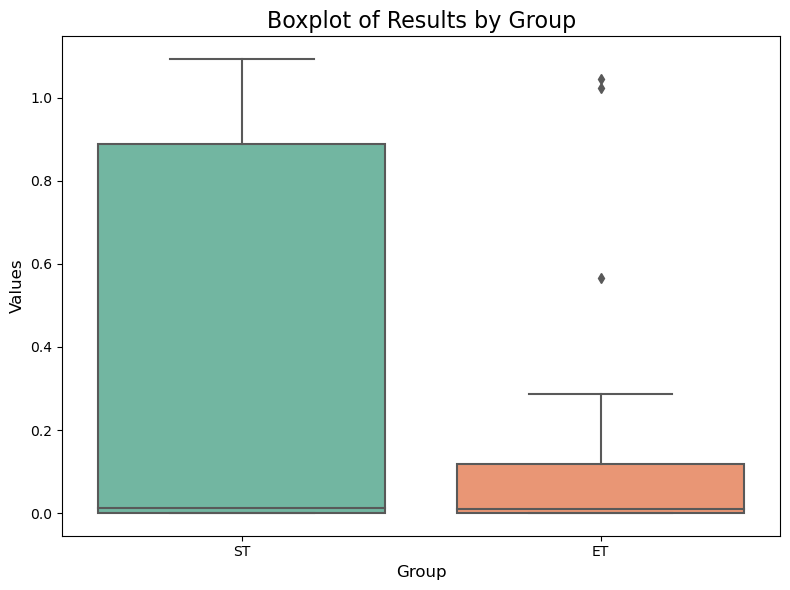

In [35]:
# Assuming your DataFrame is stored as 'df'
df = dev_lastANDtest

# Grouping by 'Group' and calculating Q1, Q3, and IQR
grouped = df.groupby('Group')['dev_percent'].describe()

# Calculating IQR and identifying outliers
def find_outliers(group):
    Q1 = group.quantile(0.25)
    Q3 = group.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = group[(group < lower_bound) | (group > upper_bound)]
    return outliers

# Apply the function to each group
outliers_dev = df.groupby('Group')['dev_percent'].apply(find_outliers)

# Print outliers
print(outliers_dev)

# Optional: visualize outliers in a boxplot
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x="Group", y='dev_percent', palette="Set2")
plt.title('Boxplot of Results by Group', fontsize=16)
plt.xlabel('Group', fontsize=12)
plt.ylabel('Values', fontsize=12)
plt.tight_layout()
plt.show()

In [36]:
dev_lastANDtest = dev_lastANDtest.reset_index()

In [37]:
outliers_dev = pd.DataFrame(outliers_dev).reset_index()
outliers_dev_subIds = outliers_dev['subId']

In [38]:
dev_lastANDtest = dev_lastANDtest[~dev_lastANDtest['subId'].isin(outliers_dev_subIds)]

In [39]:

# Convert from wide to long format
dev_lastANDtest_long = dev_lastANDtest.melt(id_vars=["Group", "SubGroup"], 
                  value_vars=["last", "dev"], 
                  var_name="Session", 
                  value_name="CorrectResponses")

In [40]:
dev_lastANDtest_long.dropna()

,Group,SubGroup,Session,CorrectResponses
0,ST,ST_Left,last,0.918033
1,ST,ST_Left,last,0.703704
2,ST,ST_Left,last,0.936508
3,ST,ST_Left,last,0.888889
4,ST,ST_Left,last,0.479167
...,...,...,...,...
75,ET,ET_Right,dev,0.000000
76,ET,ET_Right,dev,0.040650
77,ET,ET_Right,dev,0.222222
78,ET,ET_Right,dev,0.000000


In [41]:
dev_lastANDtest_long.to_csv('dev_lastANDtest_long1.csv')

In [42]:
from scipy.stats import shapiro

# Test normality for each measure
print("Shapiro-Wilk test for 'last':", shapiro(dev_lastANDtest['last']))
print("Shapiro-Wilk test for 'dev':", shapiro(dev_lastANDtest['dev_percent']))


Shapiro-Wilk test for 'last': ShapiroResult(statistic=0.8226556777954102, pvalue=2.083195431623608e-05)
Shapiro-Wilk test for 'dev': ShapiroResult(statistic=0.6279107332229614, pvalue=7.67854846372984e-09)


### Create plot for DEV results

In [44]:
et_per = (etDevResults[0]/et_last_devResults[0]).dropna()
et_per = et_per.reset_index()
et_per["Group"] = "ET"
st_per = (stDevResults[0]/st_last_devResults[0]).dropna()
st_per = st_per.reset_index()
st_per["Group"] = "ST"

In [45]:
ET_Left = (dev13/last_dev13)
ET_Left = ET_Left.reset_index()
ET_Left["Group"] = "ET_Left"
ST_Left = (dev11/last_dev11)
ST_Left = ST_Left.reset_index()
ST_Left["Group"] = "ST_Left"
ET_Right = (dev14/last_dev14)
ET_Right = ET_Right.reset_index()
ET_Right["Group"] = "ET_Right"
ST_Right = (dev12/last_dev12)
ST_Right = ST_Right.reset_index()
ST_Right["Group"] = "ST_Right"
split = pd.DataFrame([0])
split['subId'] = [1]
split["SubGroup"] = 'Split'
# split["dev"] = [0]


#### Figs for Devaluation

In [47]:
data_et_dev = dev_lastANDtest[dev_lastANDtest['Group'] == 'ET']['dev']
data_st_dev = dev_lastANDtest[dev_lastANDtest['Group'] == 'ST']['dev']


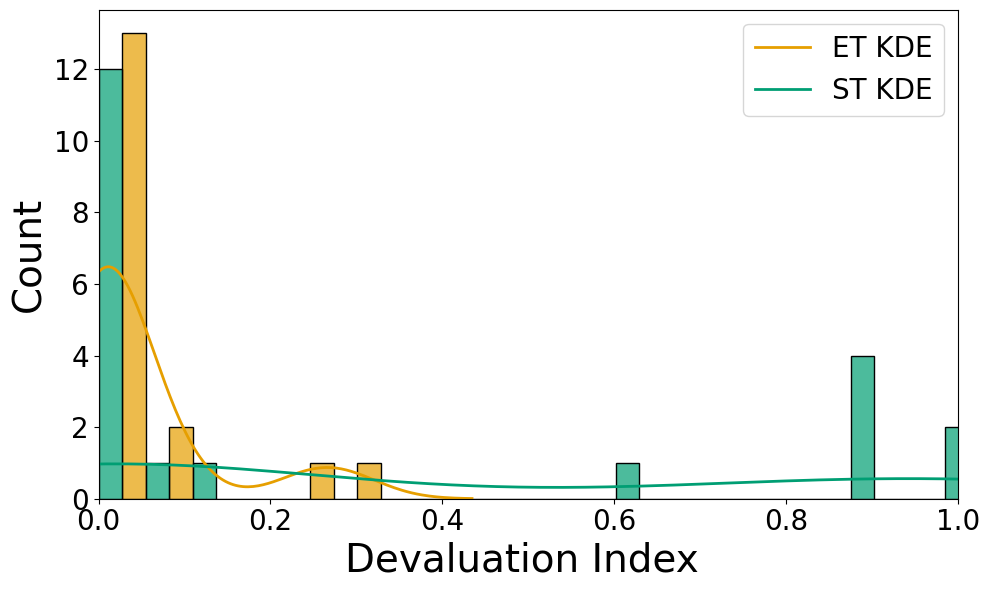

In [48]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = dev_lastANDtest

# Define the palette
palette = {"ET": "#E69F00", "ST": "#009E73"}

# Set figure size
plt.figure(figsize=(10, 6))

# Define bins (same for both groups)
num_bins = 20  # Adjust as needed
bin_min = df["dev_percent"].min()
bin_max = df["dev_percent"].max()
bins = np.linspace(bin_min, bin_max, num_bins + 1)  # Ensure equal bin widths

# Create histogram with dodged bars (bars next to each other)
sns.histplot(
    data=df,
    x="dev_percent",
    hue="Group",
    bins=bins,
    multiple="dodge",  # Ensures bars are next to each other
    palette=palette,
    alpha=0.7,  # Transparency to make it clearer
    legend=True
)

# Overlay KDE plots
for group, color in palette.items():
    sns.kdeplot(
        data=df[df["Group"] == group],
        x="dev_percent",
        color=color,
        linewidth=2,
        label=f"{group} KDE"
    )

# Labels and title
plt.xlabel("Devaluation Index ", fontsize=28)
plt.ylabel("Count", fontsize=28)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

plt.xlim(0,1)
# Ensure the legend is visible
plt.legend(title="Group")
plt.legend(fontsize=20)  # Adjust the font size as needed
# Save and show
plt.tight_layout()
plt.savefig("dev_test_histogram_kde_dodged_pilot1.png", dpi=300, bbox_inches="tight")
plt.show()


In [49]:
split = split.rename(columns={0:'dev'})
split_ET_Left = pd.concat([dev13[['dev','SubGroup']], split])
split_ET_Right = pd.concat([dev14[['dev','SubGroup']], split])
split_ST_Left = pd.concat([dev11[['dev','SubGroup']], split])
split_ST_Right = pd.concat([dev12[['dev','SubGroup']], split])

/var/folders/nq/v984r81x1fl7rkw1hk0cs6hc0000gr/T/ipykernel_82505/4090806974.py:42: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(


<Figure size 200x100 with 0 Axes>

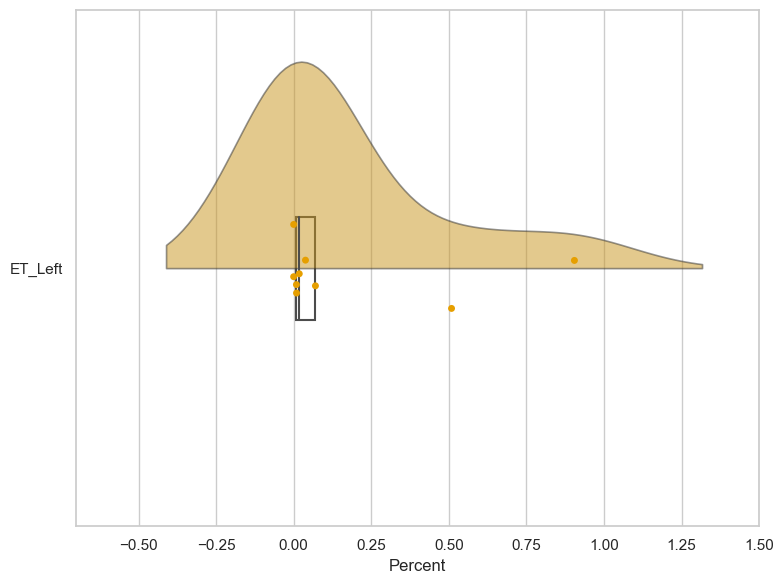

In [50]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


df = split_ET_Left
plt.figure(figsize=(2,1))  # Set figure size before plotting

# Set style
sns.set(style="whitegrid")
# Define color palette (Make "Split" semi-transparent)
palette = {"ET_Left": "#E69F00", "Split": "#009E73"}  # Orange for main, Green for Split

# Set up the plot
fig, ax = plt.subplots(figsize=(8, 6))

# Create the violin plot, splitting by 'Group'
vplot = sns.violinplot(
    data=df, x='dev', y="SubGroup", ax=ax, hue="SubGroup",
    inner=None, linewidth=1.2, scale="width", split=True, 
    palette=palette, alpha=0.9  # Semi-transparent Split group
)
# Manually change transparency of the violin
for violin in vplot.collections:
        violin.set_alpha(0.5)  # Set transparency manually
        
        
# Overlay a boxplot
sns.boxplot(
    data=df[df["SubGroup"] == "ET_Left"],  # Filter only "ET_Left" rows
    x='dev',  # X-axis should use "Percent"
    y="SubGroup",  # Keep y as "Group" for correct positioning
    ax=ax, 
    width=0.2, 
    fliersize=0, 
    showcaps=False, 
    boxprops={"facecolor": "none"},  # Transparent boxplot
    whiskerprops={"linewidth": 0}
)

# Overlay strip plot for individual points
sns.stripplot(
    data=df, x='dev', y="SubGroup", ax=ax, jitter=True, size=5, 
    alpha=1, palette=palette
)

# Titles and labels
# ax.set_title("Pilot 1 - ET Left Devaluation", fontsize=14)
ax.set_xlabel("Percent")
ax.set_ylabel("")
ax.legend_.remove()
ax.set_xlim(-0.7, 1.5)
plt.tight_layout()
plt.savefig('ET - Left Devaluation.png', dpi=300, bbox_inches='tight')  # Save as PNG (you can change the file format)
plt.show()


/var/folders/nq/v984r81x1fl7rkw1hk0cs6hc0000gr/T/ipykernel_82505/1951295376.py:42: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(


<Figure size 200x100 with 0 Axes>

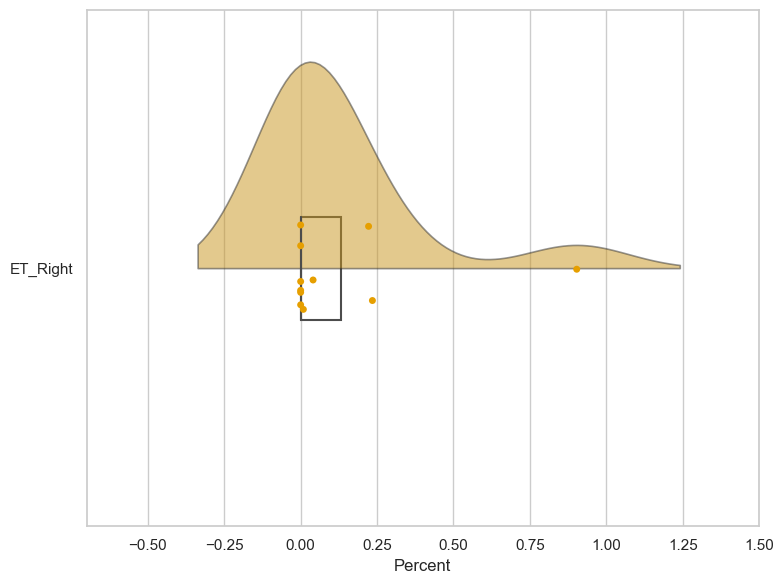

In [51]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


df = split_ET_Right
plt.figure(figsize=(2,1))  # Set figure size before plotting

# Set style
sns.set(style="whitegrid")
# Define color palette (Make "Split" semi-transparent)
palette = {"ET_Right": "#E69F00", "Split": "#009E73"}  # Orange for main, Green for Split

# Set up the plot
fig, ax = plt.subplots(figsize=(8, 6))

# Create the violin plot, splitting by 'Group'
vplot = sns.violinplot(
    data=df, x='dev', y="SubGroup", ax=ax, hue="SubGroup",
    inner=None, linewidth=1.2, scale="width", split=True, 
    palette=palette, alpha=0.9  # Semi-transparent Split group
)
# Manually change transparency of the violin
for violin in vplot.collections:
        violin.set_alpha(0.5)  # Set transparency manually
        
        
# Overlay a boxplot
sns.boxplot(
    data=df[df["SubGroup"] == "ET_Right"],  # Filter only "ET_Left" rows
    x='dev',  # X-axis should use "Percent"
    y="SubGroup",  # Keep y as "Group" for correct positioning
    ax=ax, 
    width=0.2, 
    fliersize=0, 
    showcaps=False, 
    boxprops={"facecolor": "none"},  # Transparent boxplot
    whiskerprops={"linewidth": 0}
)

# Overlay strip plot for individual points
sns.stripplot(
    data=df, x='dev', y="SubGroup", ax=ax, jitter=True, size=5, 
    alpha=1, palette=palette
)

# Titles and labels
# ax.set_title("Pilot 1 - ET Right Devaluation", fontsize=14)
ax.set_xlabel("Percent")
ax.set_ylabel("")
ax.legend_.remove()
ax.set_xlim(-0.7, 1.5)
plt.tight_layout()
plt.savefig('ET - Right Devaluation.png', dpi=300, bbox_inches='tight')  # Save as PNG (you can change the file format)
plt.show()


/var/folders/nq/v984r81x1fl7rkw1hk0cs6hc0000gr/T/ipykernel_82505/386265186.py:42: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(


<Figure size 200x100 with 0 Axes>

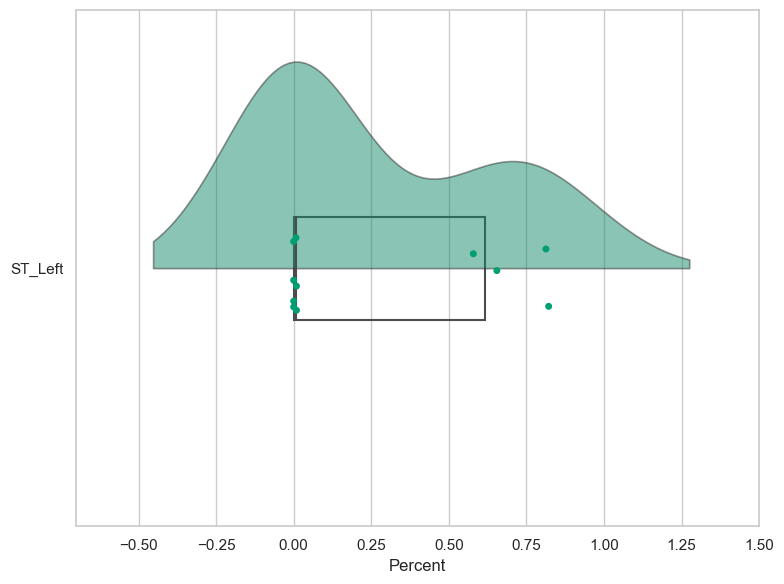

In [52]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


df = split_ST_Left
plt.figure(figsize=(2,1))  # Set figure size before plotting

# Set style
sns.set(style="whitegrid")
# Define color palette (Make "Split" semi-transparent)
palette = {"ST_Left": "#009E73", "Split": "#E69F00"}  # Orange for main, Green for Split

# Set up the plot
fig, ax = plt.subplots(figsize=(8, 6))

# Create the violin plot, splitting by 'Group'
vplot = sns.violinplot(
    data=df, x='dev', y="SubGroup", ax=ax, hue="SubGroup",
    inner=None, linewidth=1.2, scale="width", split=True, 
    palette=palette, alpha=0.9  # Semi-transparent Split group
)
# Manually change transparency of the violin
for violin in vplot.collections:
        violin.set_alpha(0.5)  # Set transparency manually
        
        
# Overlay a boxplot
sns.boxplot(
    data=df[df["SubGroup"] == "ST_Left"],  # Filter only "ET_Left" rows
    x='dev',  # X-axis should use "Percent"
    y="SubGroup",  # Keep y as "Group" for correct positioning
    ax=ax, 
    width=0.2, 
    fliersize=0, 
    showcaps=False, 
    boxprops={"facecolor": "none"},  # Transparent boxplot
    whiskerprops={"linewidth": 0}
)

# Overlay strip plot for individual points
sns.stripplot(
    data=df, x='dev', y="SubGroup", ax=ax, jitter=True, size=5, 
    alpha=1, palette=palette
)

# Titles and labels
# ax.set_title("Pilot 1 - ST Left Devaluation", fontsize=14)
ax.set_xlabel("Percent")
ax.set_ylabel("")
ax.legend_.remove()
ax.set_xlim(-0.7, 1.5)
plt.tight_layout()
plt.savefig('ST - Left Devaluation.png', dpi=300, bbox_inches='tight')  # Save as PNG (you can change the file format)
plt.show()


/var/folders/nq/v984r81x1fl7rkw1hk0cs6hc0000gr/T/ipykernel_82505/2175410123.py:42: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(


<Figure size 200x100 with 0 Axes>

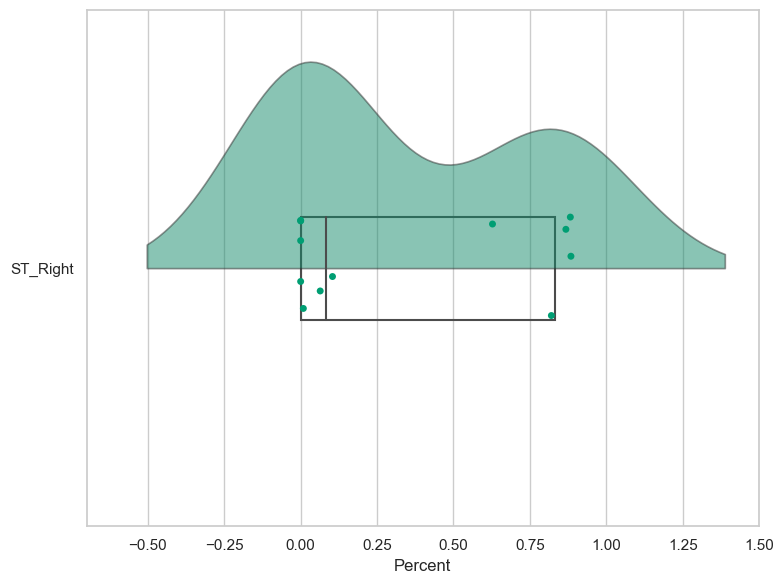

In [53]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


df = split_ST_Right
plt.figure(figsize=(2,1))  # Set figure size before plotting

# Set style
sns.set(style="whitegrid")
# Define color palette (Make "Split" semi-transparent)
palette = {"ST_Right": "#009E73", "Split": "#E69F00"}  # Orange for main, Green for Split

# Set up the plot
fig, ax = plt.subplots(figsize=(8, 6))

# Create the violin plot, splitting by 'Group'
vplot = sns.violinplot(
    data=df, x='dev', y="SubGroup", ax=ax, hue="SubGroup",
    inner=None, linewidth=1.2, scale="width", split=True, 
    palette=palette, alpha=0.9  # Semi-transparent Split group
)
# Manually change transparency of the violin
for violin in vplot.collections:
        violin.set_alpha(0.5)  # Set transparency manually
        
        
# Overlay a boxplot
sns.boxplot(
    data=df[df["SubGroup"] == "ST_Right"],  # Filter only "ET_Left" rows
    x='dev',  # X-axis should use "Percent"
    y="SubGroup",  # Keep y as "Group" for correct positioning
    ax=ax, 
    width=0.2, 
    fliersize=0, 
    showcaps=False, 
    boxprops={"facecolor": "none"},  # Transparent boxplot
    whiskerprops={"linewidth": 0}
)

# Overlay strip plot for individual points
sns.stripplot(
    data=df, x='dev', y="SubGroup", ax=ax, jitter=True, size=5, 
    alpha=1, palette=palette
)

# Titles and labels
# ax.set_title("Pilot 1 - ST Right Devaluation", fontsize=14)
ax.set_xlabel("Percent")
ax.set_ylabel("")
ax.legend_.remove()
ax.set_xlim(-0.7, 1.5)
plt.tight_layout()
plt.savefig('ST - Right Devaluation.png', dpi=300, bbox_inches='tight')  # Save as PNG (you can change the file format)
plt.show()


In [54]:
stDevResults.rename(columns={0: 'percent'}, inplace=True)
etDevResults.rename(columns={0: 'percent'}, inplace=True)

In [55]:
stDevResults = stDevResults.reset_index()
stDevResults['Group']= 'ST'
etDevResults = etDevResults.reset_index()
etDevResults['Group']= 'ET'
stDevResults.drop('subId', axis=1, inplace=True)
etDevResults.drop('subId', axis=1, inplace=True)

### Yellow & star tests:

In [56]:
st_count_Results = pd.concat([results_additional[11], results_additional[12]], axis=0)
et_count_Results = pd.concat([results_additional[13], results_additional[14]], axis=0)
choices11 = pd.DataFrame([results_main[11].yellowChoiceYellow.groupby('subId').sum(), results_main[11].allStars.groupby('subId').sum()]).T
choices12 = pd.DataFrame([results_main[12].yellowChoiceYellow.groupby('subId').sum(), results_main[12].allStars.groupby('subId').sum()]).T
choices13 = pd.DataFrame([results_main[13].yellowChoiceYellow.groupby('subId').sum(), results_main[13].allStars.groupby('subId').sum()]).T
choices14 = pd.DataFrame([results_main[14].yellowChoiceYellow.groupby('subId').sum(), results_main[14].allStars.groupby('subId').sum()]).T
st_choice_Results = pd.concat([choices11, choices12], axis=0)
et_choice_Results = pd.concat([choices13, choices14], axis=0)


In [57]:
st_accuracyCount_yellow = pd.DataFrame(1-(abs(st_choice_Results['yellowChoiceYellow']-st_count_Results['howManyYellows'])/st_choice_Results['yellowChoiceYellow']))
st_accuracyCount_yellow['Group'] = 'ST'
et_accuracyCount_yellow = pd.DataFrame(1-(abs(et_choice_Results['yellowChoiceYellow']-et_count_Results['howManyYellows'])/et_choice_Results['yellowChoiceYellow']))
et_accuracyCount_yellow['Group'] = 'ET'
st_accuracyCount_star = pd.DataFrame(1-(abs(st_choice_Results['allStars']-st_count_Results['howManyStars'])/st_choice_Results['allStars']))
st_accuracyCount_star['Group'] = 'ST'
et_accuracyCount_star = pd.DataFrame(1-(abs(et_choice_Results['allStars']-et_count_Results['howManyStars'])/et_choice_Results['allStars']))
et_accuracyCount_star['Group'] = 'ET'

In [58]:
accuracyCount_star = pd.concat([st_accuracyCount_star,et_accuracyCount_star])

#### Outliers stars

Group  subId                   
ET     64a683c2aa154e67c58b9726    0.733333
ST     64a6832daa154e67c58b971b    0.705882
       64a6832daa154e67c58b971d    0.631579
       64a6832daa154e67c58b971e    0.714286
Name: 0, dtype: float64


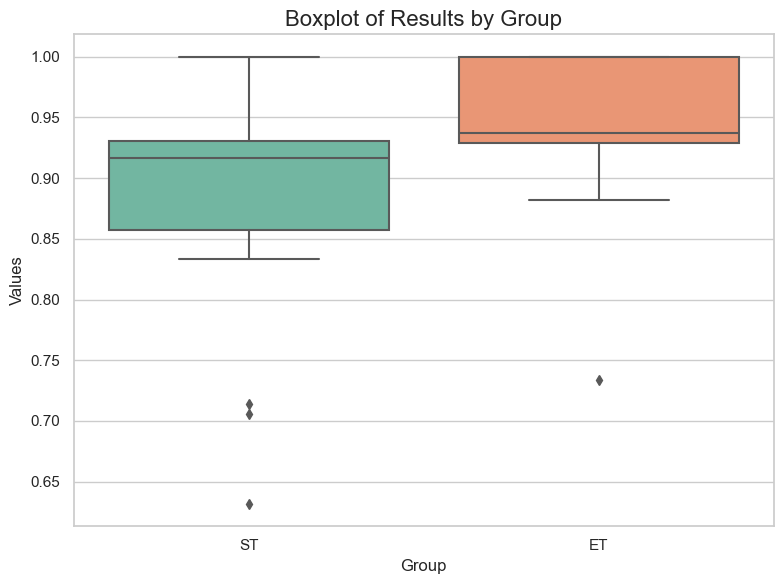

In [59]:
# Assuming your DataFrame is stored as 'df'
df = accuracyCount_star

# Grouping by 'Group' and calculating Q1, Q3, and IQR
grouped = df.groupby('Group')[0].describe()

# Calculating IQR and identifying outliers
def find_outliers(group):
    Q1 = group.quantile(0.25)
    Q3 = group.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = group[(group < lower_bound) | (group > upper_bound)]
    return outliers

# Apply the function to each group
outliers_stars = df.groupby('Group')[0].apply(find_outliers)

# Print outliers
print(outliers_stars)

# Optional: visualize outliers in a boxplot
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x="Group", y=0, palette="Set2")
plt.title('Boxplot of Results by Group', fontsize=16)
plt.xlabel('Group', fontsize=12)
plt.ylabel('Values', fontsize=12)
plt.tight_layout()
plt.show()


In [60]:
accuracyCount_star = accuracyCount_star.reset_index()

In [61]:
outliers_starts = pd.DataFrame(outliers_stars).reset_index()
outliersStars_subIds = outliers_starts['subId']

In [62]:
df_stars_cleaned = accuracyCount_star[~accuracyCount_star['subId'].isin(outliersStars_subIds)]

#### Stars stats and plot

In [63]:
df_stars_cleaned#[df_stars_cleaned['Group']=='ET'].describe()

,subId,0,Group
0,64a67fb0aa154e67c58b9707,0.933333,ST
1,64a67fb0aa154e67c58b9708,0.928571,ST
2,64a67fb0aa154e67c58b9709,0.941176,ST
3,64a67fb0aa154e67c58b970a,0.875000,ST
4,64a67fb0aa154e67c58b970b,0.842105,ST
5,64a67fb0aa154e67c58b970d,0.928571,ST
6,64a67fb0aa154e67c58b970e,0.894737,ST
7,64a67fb0aa154e67c58b970f,0.857143,ST
8,64a67fb0aa154e67c58b9710,0.933333,ST
9,64b65bbcd2c8fb647d0ad8db,0.875000,ST


In [64]:
# Test normality for each measure
print("Shapiro-Wilk test for 'ST':", shapiro(df_stars_cleaned[df_stars_cleaned['Group'] == 'ST'][0]))
print("Shapiro-Wilk test for 'ET':", shapiro(df_stars_cleaned[df_stars_cleaned['Group'] == 'ET'][0]))

Shapiro-Wilk test for 'ST': ShapiroResult(statistic=0.9074423313140869, pvalue=0.05698157101869583)
Shapiro-Wilk test for 'ET': ShapiroResult(statistic=0.8491439819335938, pvalue=0.006496956571936607)


In [65]:
# from scipy.stats import ttest_ind
# statistic, p_value = ttest_ind(df_stars_cleaned[df_stars_cleaned['Group']=='ST'][0], df_stars_cleaned[df_stars_cleaned['Group']=='ET'][0])
# print(statistic, p_value)
from scipy.stats import mannwhitneyu, norm
import numpy as np

# Extract data for the two groups
group_ST = df_stars_cleaned[df_stars_cleaned['Group'] == 'ST'][0]
group_ET = df_stars_cleaned[df_stars_cleaned['Group'] == 'ET'][0]

# Perform Mann-Whitney U test
U_stat, p_value = mannwhitneyu(group_ST, group_ET)

# Compute effect size (r) using the Z-score method
n_ST, n_ET = len(group_ST), len(group_ET)
z_score = norm.ppf(1 - p_value / 2)  # Convert p-value to Z-score
effect_size_r = z_score / np.sqrt(n_ST + n_ET)  # r = Z / sqrt(N)

# Print results
print(f"Mann-Whitney U test: U = {U_stat:.2f}, p-value = {p_value:.6f}")
print(f"Effect size (r) = {effect_size_r:.3f}")



Mann-Whitney U test: U = 81.50, p-value = 0.002238
Effect size (r) = 0.489


/var/folders/nq/v984r81x1fl7rkw1hk0cs6hc0000gr/T/ipykernel_82505/337594286.py:12: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(


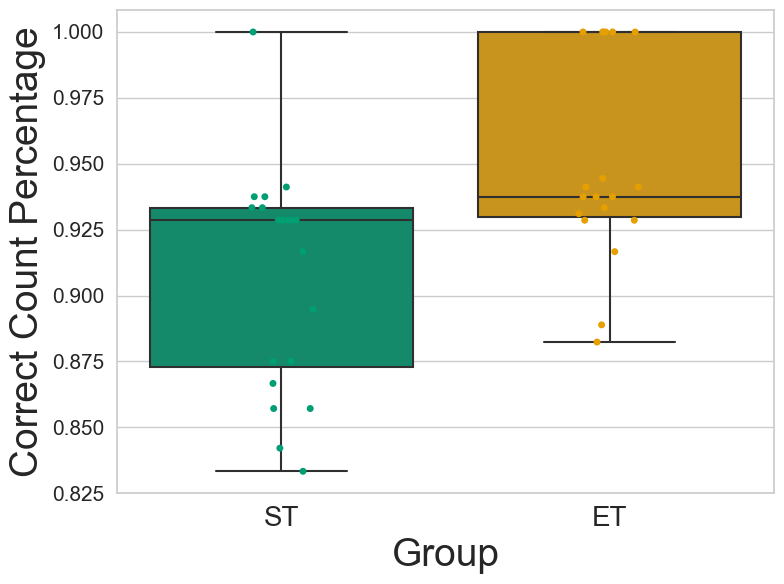

In [66]:

# Assuming your DataFrame is stored as 'df'
df = df_stars_cleaned  # Your DataFrame

# Create the plot
plt.figure(figsize=(8, 6))  # Set figure size

palette = {"ET": "#E69F00", "ST": "#009E73"}
# Create the boxplot
sns.boxplot(data=df, x="Group", y=0, palette=palette)  # Boxplot for the values

# Overlay strip plot for individual points
sns.stripplot(
    data=df, x="Group", y=0, jitter=True, size=5, alpha=1, palette=palette
)  # Stripplot on top of the boxplot

# Title and labels
plt.xlabel('Group', fontsize=28)
plt.ylabel('Correct Count Percentage', fontsize=28)
# plt.tick_params(axis='both', labelsize=20)  # Adjust the label size as needed
plt.xticks(fontsize=20)
plt.yticks(fontsize=15)

# Show the plot
plt.tight_layout()
plt.savefig('Automaticity test - Pilot 1.png', dpi=300, bbox_inches='tight')  # Save as PNG (you can change the file format)

plt.show()


### Yellow count results

In [67]:
accuracyCount_yellow = pd.concat([st_accuracyCount_yellow, et_accuracyCount_yellow])#.drop(columns=['index'])

Group  subId                   
ET     64a68463aa154e67c58b9732    0.000000
       64a68463aa154e67c58b9736    0.818182
Name: 0, dtype: float64


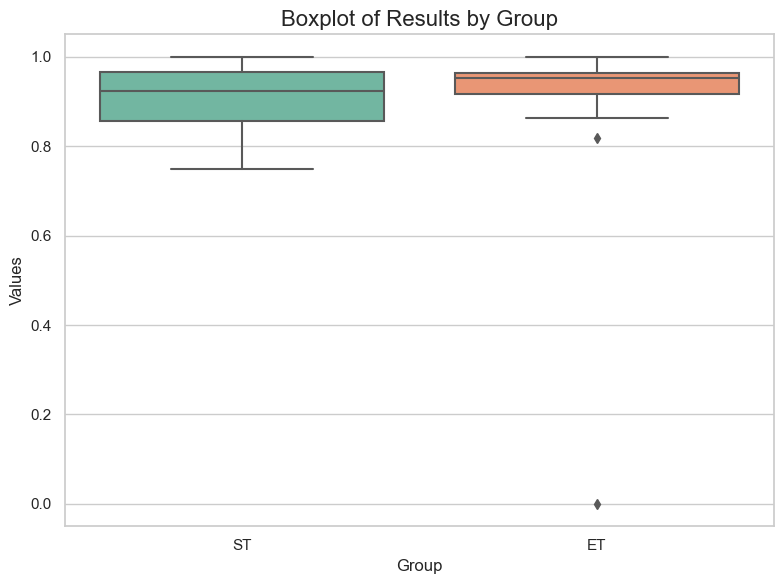

In [68]:
# Assuming your DataFrame is stored as 'df'
df = accuracyCount_yellow

# Grouping by 'Group' and calculating Q1, Q3, and IQR
grouped = df.groupby('Group')[0].describe()

# Calculating IQR and identifying outliers
def find_outliers(group):
    Q1 = group.quantile(0.25)
    Q3 = group.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = group[(group < lower_bound) | (group > upper_bound)]
    return outliers

# Apply the function to each group
outliers_yellow = df.groupby('Group')[0].apply(find_outliers)

# Print outliers
print(outliers_yellow)

# Optional: visualize outliers in a boxplot
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x="Group", y=0, palette="Set2")
plt.title('Boxplot of Results by Group', fontsize=16)
plt.xlabel('Group', fontsize=12)
plt.ylabel('Values', fontsize=12)
plt.tight_layout()
plt.show()


In [69]:
outliers_yellow = pd.DataFrame(outliers_yellow).reset_index()
outliersYellow_subIds = outliers_yellow['subId']

In [70]:
accuracyCount_yellow = accuracyCount_yellow.reset_index()

In [71]:
df_yellow_cleaned = accuracyCount_yellow[~accuracyCount_yellow['subId'].isin(outliersYellow_subIds)]

#### Yellow stats and plot

In [72]:
df_yellow_cleaned[df_yellow_cleaned['Group']=='ST'].describe()

,0
count,23.000000
mean,0.904838
std,0.076636
min,0.750000
25%,0.857143
50%,0.923077
75%,0.966518
max,1.000000


In [73]:
# from scipy.stats import ttest_ind
# statistic, p_value = ttest_ind(df_yellow_cleaned[df_yellow_cleaned['Group']=='ST'][0], df_yellow_cleaned[df_yellow_cleaned['Group']=='ET'][0])
# print(statistic, p_value)

In [74]:
# Test normality for each measure
print("Shapiro-Wilk test for 'ST':", shapiro(df_yellow_cleaned[df_yellow_cleaned['Group'] == 'ST'][0]))
print("Shapiro-Wilk test for 'ET':", shapiro(df_yellow_cleaned[df_yellow_cleaned['Group'] == 'ET'][0]))

Shapiro-Wilk test for 'ST': ShapiroResult(statistic=0.9191348552703857, pvalue=0.06383965164422989)
Shapiro-Wilk test for 'ET': ShapiroResult(statistic=0.9386003017425537, pvalue=0.2741968631744385)


In [75]:
df_yellow_cleaned.describe()

,0
count,41.000000
mean,0.923583
std,0.065767
min,0.750000
25%,0.892857
50%,0.931034
75%,0.967742
max,1.000000


In [76]:
# Extract data for the two groups
group_ST = df_yellow_cleaned[df_yellow_cleaned['Group'] == 'ST'][0]
group_ET = df_yellow_cleaned[df_yellow_cleaned['Group'] == 'ET'][0]

# Perform independent t-test
statistic, p_value = ttest_ind(group_ST, group_ET)

# Compute Cohen's d
mean_ST, mean_ET = np.mean(group_ST), np.mean(group_ET)
std_ST, std_ET = np.std(group_ST, ddof=1), np.std(group_ET, ddof=1)  # Sample std deviation
n_ST, n_ET = len(group_ST), len(group_ET)

# Pooled standard deviation
s_pooled = np.sqrt(((n_ST - 1) * std_ST**2 + (n_ET - 1) * std_ET**2) / (n_ST + n_ET - 2))

# Compute Cohen’s d
cohens_d = (mean_ST - mean_ET) / s_pooled

# Print results
print(f"T-test: t = {statistic:.2f}, p-value = {p_value:.6f}")
print(f"Cohen's d = {cohens_d:.3f}")


T-test: t = -2.15, p-value = 0.037406
Cohen's d = -0.678


/var/folders/nq/v984r81x1fl7rkw1hk0cs6hc0000gr/T/ipykernel_82505/232670249.py:12: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.stripplot(


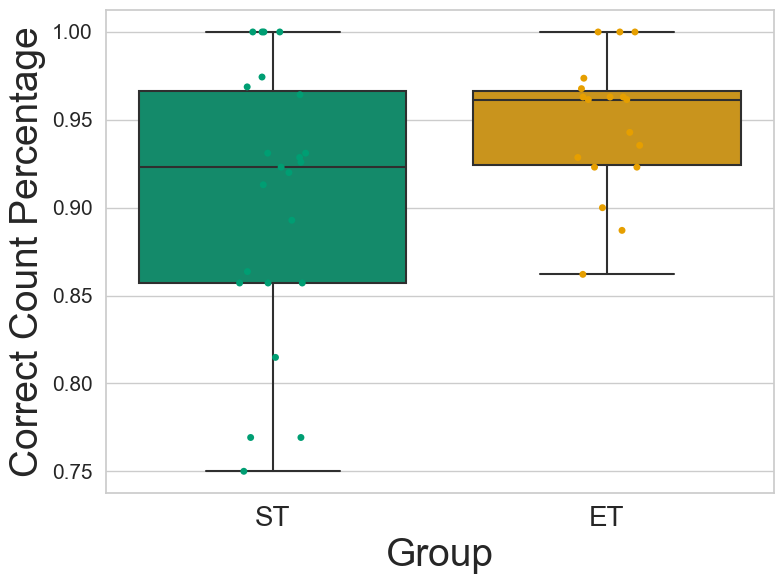

In [77]:

# Assuming your DataFrame is stored as 'df'
df = df_yellow_cleaned  # Your DataFrame

# Create the plot
plt.figure(figsize=(8, 6))  # Set figure size

palette = {"ET": "#E69F00", "ST": "#009E73"}
# Create the boxplot
sns.boxplot(data=df, x="Group", y=0, palette=palette)  # Boxplot for the values

# Overlay strip plot for individual points
sns.stripplot(
    data=df, x="Group", y=0, jitter=True, size=5, alpha=1, palette=palette
)  # Stripplot on top of the boxplot

# Title and labels
plt.xlabel('Group', fontsize=28)
plt.ylabel('Correct Count Percentage', fontsize=28)
plt.xticks(fontsize=20)
plt.yticks(fontsize=15)
# Show the plot
plt.tight_layout()
plt.savefig('Inflexibility test.png', dpi=300, bbox_inches='tight')  # Save as PNG (you can change the file format)

plt.show()


In [78]:
df_yellow_cleaned[df_yellow_cleaned['Group']=='ET'].describe()

,0
count,18.000000
mean,0.947535
std,0.038651
min,0.862069
25%,0.924451
50%,0.961538
75%,0.966547
max,1.000000


#### Stars and Yellow presses

In [79]:
accuracy_press11 = pd.DataFrame([(results_main[11].correctFirstBluePressStar.groupby('subId').sum()+results_main[11].correctFirstRedPressStar.groupby('subId').sum())/(results_main[11].blueChoiceStar.groupby('subId').sum()+\
results_main[11].redChoiceStar.groupby('subId').sum()), (results_main[11].correctFirstBluePressYellow.groupby('subId').sum()+results_main[11].correctFirstRedPressYellow.groupby('subId').sum())/results_main[11].allChoicesYellow.groupby('subId').sum()]).T.rename(columns={0: 'Stars', 1: 'Yellow'})
accuracy_press12 = pd.DataFrame([(results_main[12].correctFirstBluePressStar.groupby('subId').sum()+results_main[12].correctFirstRedPressStar.groupby('subId').sum())/(results_main[12].blueChoiceStar.groupby('subId').sum()+\
results_main[12].redChoiceStar.groupby('subId').sum()), (results_main[12].correctFirstBluePressYellow.groupby('subId').sum()+results_main[12].correctFirstRedPressYellow.groupby('subId').sum())/(results_main[12]\
.allChoicesYellow.groupby('subId').sum())]).T.rename(columns={0: 'Stars', 1: 'Yellow'})
accuracy_press13 = pd.DataFrame([(results_main[13].correctFirstBluePressStar.groupby('subId').sum()+results_main[13].correctFirstRedPressStar.groupby('subId').sum())/(results_main[13].blueChoiceStar.groupby('subId').sum()+\
results_main[13].redChoiceStar.groupby('subId').sum()), (results_main[13].correctFirstBluePressYellow.groupby('subId').sum()+results_main[13].correctFirstRedPressYellow.groupby('subId').sum())/(results_main[13]\
.allChoicesYellow.groupby('subId').sum())]).T.rename(columns={0: 'Stars', 1: 'Yellow'})
accuracy_press14 = pd.DataFrame([(results_main[14].correctFirstBluePressStar.groupby('subId').sum()+results_main[14].correctFirstRedPressStar.groupby('subId').sum())/(results_main[14].blueChoiceStar.groupby('subId').sum()+\
results_main[14].redChoiceStar.groupby('subId').sum()), (results_main[14].correctFirstBluePressYellow.groupby('subId').sum()+results_main[14].correctFirstRedPressYellow.groupby('subId').sum())/(results_main[14]\
.allChoicesYellow.groupby('subId').sum())]).T.rename(columns={0: 'Stars', 1: 'Yellow'})
st_accuracyPress_Results = pd.concat([accuracy_press11, accuracy_press12], axis=0)
st_accuracyPress_Results['Group'] = 'ST'
et_accuracyPress_Results = pd.concat([accuracy_press13, accuracy_press14], axis=0)
et_accuracyPress_Results['Group'] = 'ET'

In [80]:
accuracyPress_Results = pd.concat([st_accuracyPress_Results, et_accuracyPress_Results])

In [81]:
accuracyPress_Results_stars = accuracyPress_Results[['Stars','Group']]
accuracyPress_Results_yellow = accuracyPress_Results[['Yellow','Group']]

#### Outliers yellow

In [83]:
# Assuming your DataFrame is stored as 'df'
df = df_yellow_cleaned

# Grouping by 'Group' and calculating Q1, Q3, and IQR
grouped = df.groupby('Group')[0].describe()

# Calculating IQR and identifying outliers
# Apply the function to each group
outliers_yellow_press = df.groupby('Group')[0].apply(find_outliers)

# Print outliers
print(outliers_yellow_press)


Series([], Name: 0, dtype: float64)


In [84]:
outliers_yellow_press

Series([], Name: 0, dtype: float64)

In [85]:
# outliers_yellow_press = pd.DataFrame(outliers).reset_index()
# outliersYellowPress_subIds = outliers_yellow_press['subId']
# accuracyPress_Results_yellow = accuracyPress_Results_yellow.reset_index()

In [86]:
# df_yellowPress_cleaned = accuracyPress_Results_yellow[~accuracyPress_Results_yellow['subId'].isin(outliersYellowPress_subIds)]

In [87]:
# Test normality for each measure
print("Shapiro-Wilk test for 'ST':", shapiro(accuracyPress_Results_yellow[accuracyPress_Results_yellow['Group']=='ST']['Yellow']))
print("Shapiro-Wilk test for 'ET':", shapiro(accuracyPress_Results_yellow[accuracyPress_Results_yellow['Group']=='ET']['Yellow']))

Shapiro-Wilk test for 'ST': ShapiroResult(statistic=0.9257485270500183, pvalue=0.08853808790445328)
Shapiro-Wilk test for 'ET': ShapiroResult(statistic=0.9445658922195435, pvalue=0.2920186519622803)


In [88]:
# Extract data for the two groups
group_ST = accuracyPress_Results_yellow[accuracyPress_Results_yellow['Group']=='ST']['Yellow']
group_ET = accuracyPress_Results_yellow[accuracyPress_Results_yellow['Group']=='ET']['Yellow']

# Perform independent t-test
statistic, p_value = ttest_ind(group_ST, group_ET)

# Compute Cohen's d
mean_ST, mean_ET = np.mean(group_ST), np.mean(group_ET)
std_ST, std_ET = np.std(group_ST, ddof=1), np.std(group_ET, ddof=1)  # Sample std deviation
n_ST, n_ET = len(group_ST), len(group_ET)

# Pooled standard deviation
s_pooled = np.sqrt(((n_ST - 1) * std_ST**2 + (n_ET - 1) * std_ET**2) / (n_ST + n_ET - 2))

# Compute Cohen’s d
cohens_d = (mean_ST - mean_ET) / s_pooled

# Print results
print(f"T-test: t = {statistic:.2f}, p-value = {p_value:.6f}")
print(f"Cohen's d = {cohens_d:.3f}")


T-test: t = -0.55, p-value = 0.582146
Cohen's d = -0.170


In [89]:
accuracyPress_Results_yellow.describe()#[accuracyPress_Results_yellow['Group']=='ST']['Yellow'].describe()

,Yellow
count,43.000000
mean,0.551262
std,0.074320
min,0.378049
25%,0.506098
50%,0.567901
75%,0.592593
max,0.662651


#### Stars presses

In [90]:
# Assuming your DataFrame is stored as 'df'
df = df_stars_cleaned

# Grouping by 'Group' and calculating Q1, Q3, and IQR
grouped = df.groupby('Group')[0].describe()

# Calculating IQR and identifying outliers
def find_outliers(group):
    Q1 = group.quantile(0.25)
    Q3 = group.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = group[(group < lower_bound) | (group > upper_bound)]
    return outliers

# Apply the function to each group
outliers_press_stars = df.groupby('Group')[0].apply(find_outliers)

# Print outliers
print(outliers_press_stars)


# plt.figure(figsize=(8, 6))
# sns.boxplot(data=df, x="Group", y='Stars', palette="Set2")
# plt.title('Boxplot of Results by Group', fontsize=16)
# plt.xlabel('Group', fontsize=12)
# plt.ylabel('Values', fontsize=12)
# plt.tight_layout()
# plt.show()


Series([], Name: 0, dtype: float64)


In [91]:
# Test normality for each measure
print("Shapiro-Wilk test for 'ST':", shapiro(accuracyPress_Results_stars[accuracyPress_Results_stars['Group']=='ST']['Stars']))
print("Shapiro-Wilk test for 'ET':", shapiro(accuracyPress_Results_stars[accuracyPress_Results_stars['Group']=='ET']['Stars']))

Shapiro-Wilk test for 'ST': ShapiroResult(statistic=0.9506397843360901, pvalue=0.3016972839832306)
Shapiro-Wilk test for 'ET': ShapiroResult(statistic=0.9453963041305542, pvalue=0.3025509715080261)


In [92]:

# Extract data for the two groups
group_ST = accuracyPress_Results_stars[accuracyPress_Results_stars['Group']=='ST']['Stars']
group_ET = accuracyPress_Results_stars[accuracyPress_Results_stars['Group']=='ET']['Stars']

# Perform independent t-test
statistic, p_value = ttest_ind(group_ST, group_ET)

# Compute Cohen's d
mean_ST, mean_ET = np.mean(group_ST), np.mean(group_ET)
std_ST, std_ET = np.std(group_ST, ddof=1), np.std(group_ET, ddof=1)  # Sample std deviation
n_ST, n_ET = len(group_ST), len(group_ET)

# Pooled standard deviation
s_pooled = np.sqrt(((n_ST - 1) * std_ST**2 + (n_ET - 1) * std_ET**2) / (n_ST + n_ET - 2))

# Compute Cohen’s d
cohens_d = (mean_ST - mean_ET) / s_pooled

# Print results
print(f"T-test: t = {statistic:.2f}, p-value = {p_value:.6f}")
print(f"Cohen's d = {cohens_d:.3f}")


T-test: t = -0.98, p-value = 0.331929
Cohen's d = -0.300


In [93]:
accuracyPress_Results_stars[accuracyPress_Results_stars['Group']=='ET'].describe()

,Stars
count,20.000000
mean,0.826324
std,0.063580
min,0.679012
25%,0.779423
50%,0.847613
75%,0.871461
max,0.925000


In [94]:
df_stars_cleaned = df_stars_cleaned.drop(columns=['Group'])

In [95]:
df_stars_cleaned = df_stars_cleaned.rename(columns={0:'Count'}).set_index('subId')
accuracyPress_Results_stars = accuracyPress_Results_stars.rename(columns={'Stars':'Presses'})#.drop(columns=['Group'])
stars1 = pd.concat([df_stars_cleaned, accuracyPress_Results_stars], axis=1).dropna()
stars1['Pilot'] = 1

In [96]:
stars1.to_csv('stars1.csv')

## Response Onset Time 

#### ET group

In [107]:
custom_palette = {"ET_Left": "red", "ET_Right": "blue"}
tmp_dct = {'subID': [], 'RT': [], 'Group': []}
i = 1

# Loop for ET_Left (Red)
for lst in dfs[13]['correctFirstRedPressDevtest'].dropna():
    if lst != []:
        tmp_dct['RT'] += list(lst)
        tmp_dct['subID'] += [str(i) for _ in range(len(lst))]
        tmp_dct['Group'] += ['ET_Left' for _ in range(len(lst))]
        i += 1

# Loop for ET_Right (Blue)
for lst in dfs[14]['correctFirstBluePressDevtest'].dropna():
    if lst != []:
        tmp_dct['RT'] += list(lst)
        tmp_dct['subID'] += [str(i) for _ in range(len(lst))]
        tmp_dct['Group'] += ['ET_Right' for _ in range(len(lst))]
        i += 1

# Create DataFrame
tmp_df = pd.DataFrame(tmp_dct)

# Plot using KDE plot
# sns.kdeplot(tmp_df, x='RT', hue='Group', palette=custom_palette)



In [108]:
tmp_df_ET = tmp_df

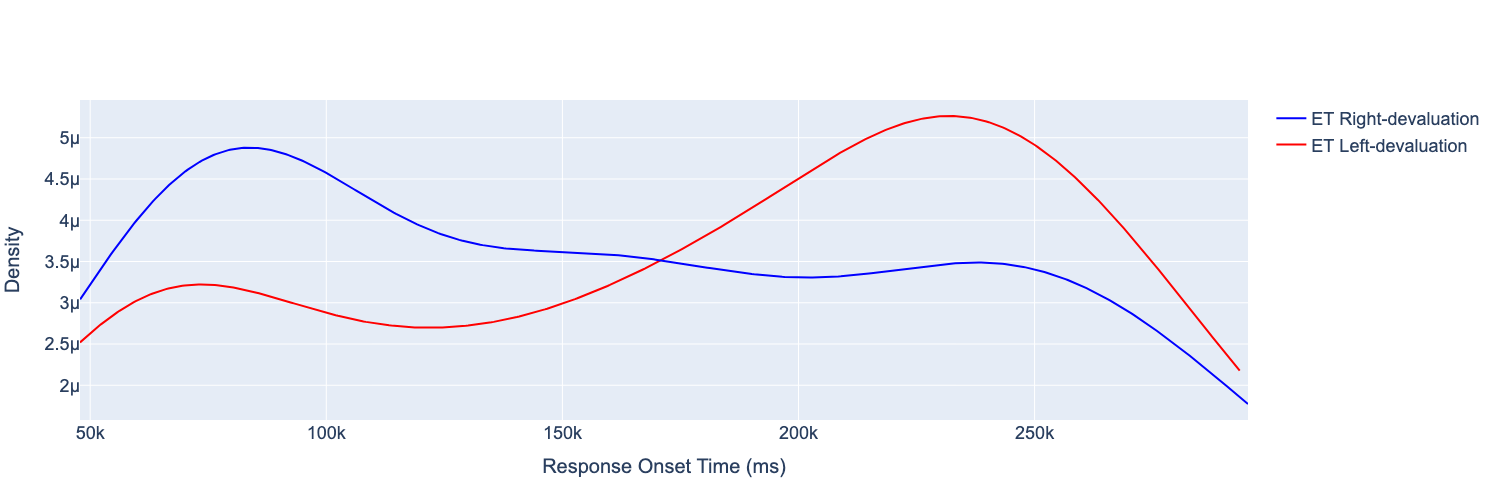

In [109]:
import plotly.figure_factory as ff

group_left = tmp_df_ET[tmp_df_ET["Group"] == "ET_Left"]["RT"]
group_right = tmp_df_ET[tmp_df_ET["Group"] == "ET_Right"]["RT"]

# Group data together
hist_data = [group_left, group_right]
group_labels = ['ET Left-devaluation', 'ET Right-devaluation']

# Custom colors: ET_Left (Red), ET_Right (Blue)
colors = ['red', 'blue']

# Create distplot with KDE only and custom colors
fig = ff.create_distplot(hist_data, group_labels, bin_size=100, show_hist=False, show_rug=False, colors=colors)

# Add title and adjust layout
fig.update_layout(
    xaxis_title="Response Onset Time (ms)",
    yaxis_title="Density",
    width=800,
    height=500,
    xaxis_title_font=dict(size=20),  # Set font size for x-axis title
    yaxis_title_font=dict(size=20),  # Set font size for y-axis title
    font=dict(
        family="Arial",  # You can change this to any font you prefer
        size=18  #
    )
)
fig.write_image("KDE_ROT_ET.png")

fig.show()


In [110]:
tmp_df_ET[tmp_df_ET["Group"] == "ET_Right"]["RT"].describe()

count       171.000000
mean     158350.853801
std       75676.389316
min       47865.000000
25%       86260.000000
50%      151686.000000
75%      229280.000000
max      295687.000000
Name: RT, dtype: float64

In [111]:
from scipy.stats import ks_2samp

# Example: Compare distributions of two groups
group_left = tmp_df_ET[tmp_df_ET["Group"] == "ET_Left"]["RT"]
group_right = tmp_df_ET[tmp_df_ET["Group"] == "ET_Right"]["RT"]


# Perform KS Test
ks_stat, p_value = ks_2samp(group_left, group_right)

# Print results
print(f"KS Statistic = {ks_stat:.4f}, p-value = {p_value:.6f}")

# Interpretation
if p_value < 0.05:
    print("Significant difference in distributions (reject null hypothesis)")
else:
    print("No significant difference in distributions (fail to reject null)")




KS Statistic = 0.1828, p-value = 0.005583
Significant difference in distributions (reject null hypothesis)


In [112]:
tmp_df[tmp_df['Group'] == 'ET_Left']['RT'].describe()

count       169.000000
mean     177509.319527
std       75135.726153
min       47842.000000
25%      110790.000000
50%      195815.000000
75%      238828.000000
max      293929.000000
Name: RT, dtype: float64

In [113]:
tmp_df[tmp_df['Group'] == 'ET_Right']['RT'].describe()

count       171.000000
mean     158350.853801
std       75676.389316
min       47865.000000
25%       86260.000000
50%      151686.000000
75%      229280.000000
max      295687.000000
Name: RT, dtype: float64

#### ST group

In [114]:
custom_palette = {"ST_Left": "red", "ST_Right": "blue"}
tmp_dct = {'subID': [], 'RT': [], 'Group': []}
i = 1

# Loop for ET_Left (Red)
for lst in dfs[11]['correctFirstRedPressDevtest'].dropna():
    if lst != []:
        tmp_dct['RT'] += list(lst)
        tmp_dct['subID'] += [str(i) for _ in range(len(lst))]
        tmp_dct['Group'] += ['ST_Left' for _ in range(len(lst))]
        i += 1

# Loop for ET_Right (Blue)
for lst in dfs[12]['correctFirstBluePressDevtest'].dropna():
    if lst != []:
        tmp_dct['RT'] += list(lst)
        tmp_dct['subID'] += [str(i) for _ in range(len(lst))]
        tmp_dct['Group'] += ['ST_Right' for _ in range(len(lst))]
        i += 1

# Create DataFrame
tmp_df_ST = pd.DataFrame(tmp_dct)
tmp_df_ST.to_csv('ST_data.csv')
# Plot using KDE plot
# sns.kdeplot(tmp_df, x='RT', hue='Group', palette=custom_palette)


In [115]:
tmp_df_ST[tmp_df_ST['Group'] == 'ST_Left']['RT'].describe()

count       502.000000
mean     183196.376494
std       69670.426409
min       47697.000000
25%      129104.500000
50%      187226.500000
75%      242905.000000
max      295932.000000
Name: RT, dtype: float64

In [116]:
tmp_df_ST[tmp_df_ST['Group'] == 'ST_Right']['RT'].describe()

count       500.000000
mean     169942.704000
std       73293.967594
min       47740.000000
25%      103838.500000
50%      170735.000000
75%      233317.500000
max      295981.000000
Name: RT, dtype: float64

In [117]:
from scipy.stats import ks_2samp

# Example: Compare distributions of two groups
group_left = tmp_df_ST[tmp_df_ST["Group"] == "ST_Left"]["RT"]
group_right = tmp_df_ST[tmp_df_ST["Group"] == "ST_Right"]["RT"]

# Perform KS Test
ks_stat, p_value = ks_2samp(group_left, group_right)

# Print results
print(f"KS Statistic = {ks_stat:.4f}, p-value = {p_value:.6f}")

# Interpretation
if p_value < 0.05:
    print("Significant difference in distributions (reject null hypothesis)")
else:
    print("No significant difference in distributions (fail to reject null)")



KS Statistic = 0.0911, p-value = 0.028743
Significant difference in distributions (reject null hypothesis)


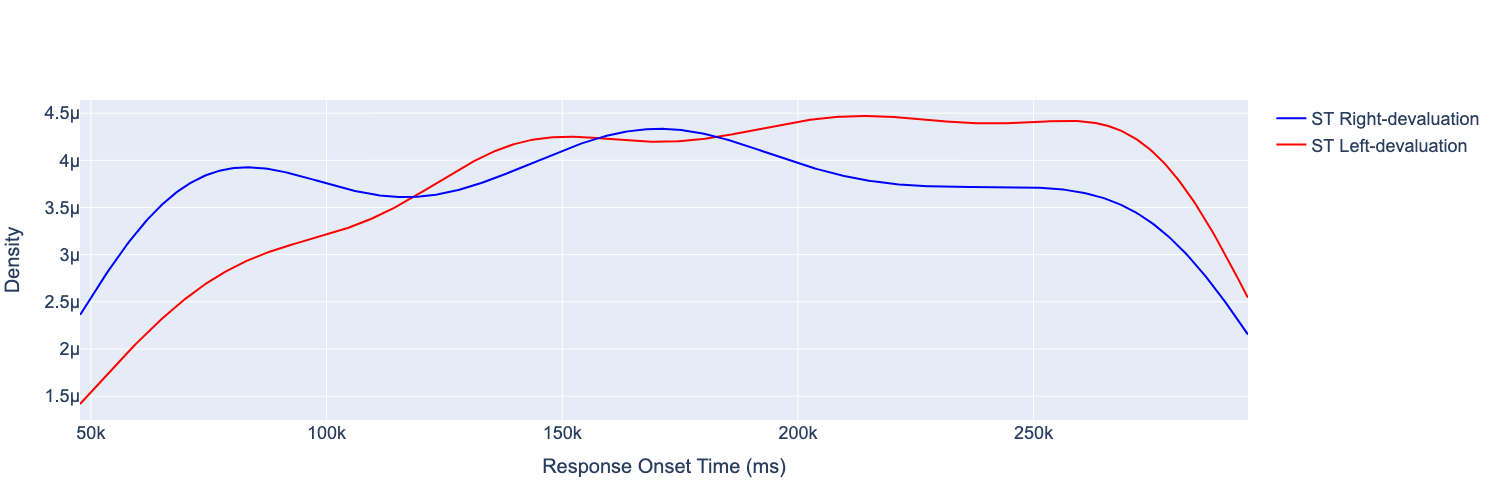

In [118]:
import plotly.figure_factory as ff

group_left = tmp_df_ST[tmp_df_ST["Group"] == "ST_Left"]["RT"]
group_right = tmp_df_ST[tmp_df_ST["Group"] == "ST_Right"]["RT"]

# Group data together
hist_data = [group_left, group_right]
group_labels = ['ST Left-devaluation', 'ST Right-devaluation']

# Custom colors: ET_Left (Red), ET_Right (Blue)
colors = ['red', 'blue']

# Create distplot with KDE only and custom colors
fig = ff.create_distplot(hist_data, group_labels, bin_size=100, show_hist=False, show_rug=False, colors=colors)

# Add title and adjust layout
fig.update_layout(
    xaxis_title="Response Onset Time (ms)",
    yaxis_title="Density",
    width=800,
    height=500,
    xaxis_title_font=dict(size=20),  # Set font size for x-axis title
    yaxis_title_font=dict(size=20),  # Set font size for y-axis title
    font=dict(
        family="Arial",  # You can change this to any font you prefer
        size=18,  
    )
)
fig.write_image("KDE_ROT_ST.png")

fig.show()


## RT

### RT for stars test

In [119]:
outliersStars = outliersStars_subIds

In [120]:
RTs = {}

for i in range(11, 15):
    RT = {}
    RT['Blue'] = {}
    RT['Red'] = {}

    # Filter relevant data
    dfs[i] = dfs[i][dfs[i].subId.isin(relevent_subIds[i])]
    dfs[i] = dfs[i][~dfs[i]['subId'].isin(outliersStars)]

    # Iterate over rows for BLUE choices
    for row in dfs[i][['subId', 'correctFirstBluePressStar', 'blueChoiceStar']].dropna().iterrows():
        RT_blue_row = {}
        subId = row[1].subId  # Extract subId

        for ind, correctFirstBluePressStar in enumerate(row[1].correctFirstBluePressStar):
            valid_choices = [x for x in row[1].blueChoiceStar if x < correctFirstBluePressStar]
            RT_blue_row[ind] = correctFirstBluePressStar - valid_choices[-1] if valid_choices else None  # Handle empty list

        if len(RT_blue_row) > 0:
            RT['Blue'][row[0]] = {'RTs': list(RT_blue_row.values()), 'subId': subId}  # Store subId

    # Iterate over rows for RED choices
    for row in dfs[i][['subId', 'correctFirstRedPressStar', 'redChoiceStar']].dropna().iterrows():
        RT_red_row = {}
        subId = row[1].subId  # Extract subId

        for ind, correctFirstRedPressStar in enumerate(row[1].correctFirstRedPressStar):
            valid_choices = [x for x in row[1].redChoiceStar if x < correctFirstRedPressStar]
            RT_red_row[ind] = correctFirstRedPressStar - valid_choices[-1] if valid_choices else None  # Handle empty list

        if len(RT_red_row) > 0:
            RT['Red'][row[0]] = {'RTs': list(RT_red_row.values()), 'subId': subId}  # Store subId

    # Convert to DataFrame
    RTs[i] = pd.DataFrame.from_dict({(key, subkey): values 
                                     for key, subdict in RT.items() 
                                     for subkey, values in subdict.items()}, 
                                     orient='index')

    # Reset index to make 'Color' and 'RowIndex' columns
    RTs[i].reset_index(inplace=True)
    RTs[i].rename(columns={'level_0': 'Color', 'level_1': 'RowIndex'}, inplace=True)

    # Ensure 'subId' is set as an index or a column
    RTs[i] = RTs[i].set_index('subId')

    # Expand dictionary values into separate columns
    RTs[i] = pd.concat([RTs[i], RTs[i].apply(lambda row: pd.Series(row[0]), axis=1)], axis=1)

    # Drop unnecessary nested dictionary column
    RTs[i].drop(columns=[0], inplace=True, errors='ignore')



In [121]:
def to_list(a):
    if isinstance(a, float):
        return [a]
    return a

In [122]:
mean_RTs = {}

for grp, RT in RTs.items():
    # Compute mean RTs while keeping 'subId'
    mean_df = RT.groupby(["subId", "Color"])["RTs"].apply(lambda x: 
        pd.Series([item for sublist in x.dropna() for item in to_list(sublist)]).mean()
    ).unstack()  # Convert 'Color' categories into separate columns

    # Store the result
    mean_RTs[grp] = mean_df.reset_index()  # Ensure 'subId' is a column


In [123]:
BandRST = pd.concat([mean_RTs[11], mean_RTs[12]]).reset_index()
BandRST["Group"]="ST"
BandRET = pd.concat([mean_RTs[13], mean_RTs[14]]).reset_index()
BandRET["Group"]="ET"
BandR = pd.concat([BandRST,BandRET])
BandR = BandR.drop(columns = "index")
BandR = BandR.rename(columns={0:"MeanRT"})#.drop(columns=['index'])

In [124]:
BandR = BandR.reset_index().melt(id_vars=['subId', 'Group'], 
                                  value_vars=['Blue', 'Red'], 
                                  var_name='Color', 
                                  value_name='MeanRT')


In [125]:
# Assuming your DataFrame is stored as 'df'
df = BandR

# Grouping by 'Group' and calculating Q1, Q3, and IQR
grouped = df.groupby('Group')['MeanRT'].describe()

# Calculating IQR and identifying outliers
def find_outliers(group):
    Q1 = group.quantile(0.25)
    Q3 = group.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = group[(group < lower_bound) | (group > upper_bound)]
    return outliers

# Apply the function to each group
outliers_RT_stars = df.groupby('Group')['MeanRT'].apply(find_outliers)

# Print outliers
print(outliers_RT_stars)

Series([], Name: MeanRT, dtype: float64)


In [126]:
outliers_RT_Stars = pd.DataFrame(outliers_RT_stars).reset_index()
outliers_RT_Stars_subIds = outliers_RT_Stars['level_1']

In [127]:
df_RT_Stars_cleaned = BandR[~BandR['subId'].isin(outliers_RT_Stars_subIds)]

In [128]:
# Test normality for each measure
print("Shapiro-Wilk test for 'ST':", shapiro(BandR[BandR['Group']=='ST']['MeanRT'].dropna()))
print("Shapiro-Wilk test for 'ET':", shapiro(BandR[BandR['Group']=='ET']['MeanRT'].dropna()))

Shapiro-Wilk test for 'ST': ShapiroResult(statistic=0.9640941023826599, pvalue=0.2306014895439148)
Shapiro-Wilk test for 'ET': ShapiroResult(statistic=0.9790210127830505, pvalue=0.6827526092529297)


In [129]:
from scipy.stats import ttest_ind
import numpy as np

# Extract data for the two groups
group_ST = BandR[BandR['Group']=='ST']['MeanRT'].dropna()
group_ET = BandR[BandR['Group']=='ET']['MeanRT'].dropna()

# Perform independent t-test
statistic, p_value = ttest_ind(group_ST, group_ET)

# Compute Cohen's d
mean_ST, mean_ET = np.mean(group_ST), np.mean(group_ET)
std_ST, std_ET = np.std(group_ST, ddof=1), np.std(group_ET, ddof=1)  # Sample std deviation
n_ST, n_ET = len(group_ST), len(group_ET)

# Pooled standard deviation
s_pooled = np.sqrt(((n_ST - 1) * std_ST**2 + (n_ET - 1) * std_ET**2) / (n_ST + n_ET - 2))

# Compute Cohen’s d
cohens_d = (mean_ST - mean_ET) / s_pooled

# Print results
print(f"T-test: t = {statistic:.2f}, p-value = {p_value:.6f}")
print(f"Cohen's d = {cohens_d:.3f}")


T-test: t = -0.96, p-value = 0.342062
Cohen's d = -0.217


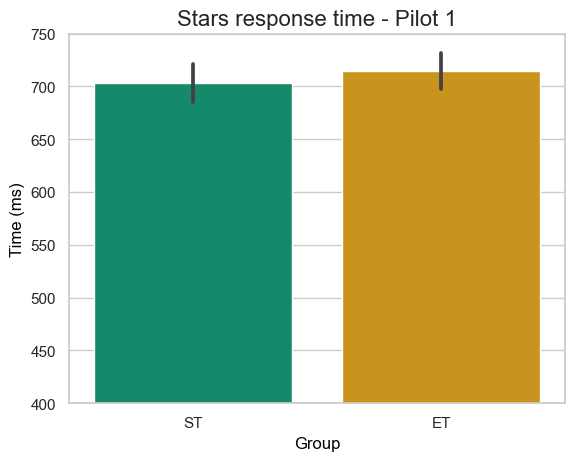

In [130]:

# Define custom colors
custom_palette = {"ET": "#E69F00", "ST": "#009E73"}

# Create the bar plot with custom colors
ax = sns.barplot(data=df_RT_Stars_cleaned, x="Group", y="MeanRT", palette=custom_palette)

# Set axis limits
plt.ylim(400, 750)

# Customize axis labels
ax.set_xlabel("Group", fontdict={'fontsize': 12, 'color': 'black'})
ax.set_ylabel("Time (ms)", fontdict={'fontsize': 12, 'color': 'black'})

plt.title('Stars response time - Pilot 1', fontsize=16)
# plt.xlabel('Group', fontsize=12)
# plt.ylabel('Correct Presses Percentage', fontsize=12)
# Save the figure
plt.savefig("response_time_stars.png")

# Show the plot
plt.show()


In [183]:
df_RT_Stars_cleaned['Pilot'] = 1
df_RT_Stars_cleaned.to_csv('df_RT_Stars_cleaned1.csv')

### RT training

In [132]:
# Create a function to filter elements in the list that are greater than 180,000 milliseconds
def filter_list_RTs(lst):
    if len([item for item in lst if isinstance(item, int) and item > 180000])==0:
           return np.nan
    return [item for item in lst if isinstance(item, int) and item > 180000]

In [133]:
dfs_for_RT_blue = {}
dfs_for_RT_red = {}
dfs_for_RT = {}

for i in range (13, 15):
    dfs_for_RT_blue[i] = dfs[i][dfs[i].subId.isin(relevent_subIds[i])]\
    .set_index(['subId',dfs[i][dfs[i].subId.isin(relevent_subIds[i])].createdAt.str[:10]])[['correctFirstBluePress', 'blueChoice']].dropna().reset_index()
    dfs_for_RT_blue[i] = dfs_for_RT_blue[i][dfs_for_RT_blue[i]['correctFirstBluePress'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
    dfs_for_RT_blue[i]['correctFirstBluePress'] = dfs_for_RT_blue[i]['correctFirstBluePress'].apply(filter_list_RTs)
    dfs_for_RT_blue[i]['blueChoice'] = dfs_for_RT_blue[i]['blueChoice'].apply(filter_list_RTs)
    dfs_for_RT_blue[i].sort_values(by='createdAt', ascending=True, inplace=True)
    dfs_for_RT_blue[i] = dfs_for_RT_blue[i].groupby('subId').apply(fix_subId)
    dfs_for_RT_blue[i] = dfs_for_RT_blue[i].drop(columns=['subId'])

    dfs_for_RT_red[i] = dfs[i][dfs[i].subId.isin(relevent_subIds[i])]\
    .set_index(['subId',dfs[i][dfs[i].subId.isin(relevent_subIds[i])].createdAt.str[:10]])[['correctFirstRedPress', 'redChoice']].dropna().reset_index()
    dfs_for_RT_red[i] = dfs_for_RT_red[i][dfs_for_RT_red[i]['correctFirstRedPress'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
    dfs_for_RT_red[i]['correctFirstRedPress'] = dfs_for_RT_red[i]['correctFirstRedPress'].apply(filter_list_RTs)
    dfs_for_RT_red[i]['redChoice'] = dfs_for_RT_red[i]['redChoice'].apply(filter_list_RTs)
    dfs_for_RT_red[i].sort_values(by='createdAt', ascending=True, inplace=True)
    dfs_for_RT_red[i] = dfs_for_RT_red[i].groupby('subId').apply(fix_subId)
    dfs_for_RT_red[i] = dfs_for_RT_red[i].drop(columns=['subId','createdAt'])

    
for i in range (11, 13):    
    dfs_for_RT_blue[i] = dfs[i][dfs[i].subId.isin(relevent_subIds[i])]\
    .set_index(['subId',dfs[i][dfs[i].subId.isin(relevent_subIds[i])].createdAt.str[:10]])[['correctFirstBluePress', 'blueChoice']].dropna().reset_index()
    dfs_for_RT_blue[i] = dfs_for_RT_blue[i][dfs_for_RT_blue[i]['correctFirstBluePress'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
    dfs_for_RT_blue[i]['correctFirstBluePress'] = dfs_for_RT_blue[i]['correctFirstBluePress'].apply(filter_list_RTs)
    dfs_for_RT_blue[i]['blueChoice'] = dfs_for_RT_blue[i]['blueChoice'].apply(filter_list_RTs)
    dfs_for_RT_blue[i].sort_values(by=['subId', 'createdAt'])
    dfs_for_RT_blue[i] = dfs_for_RT_blue[i].groupby('subId', as_index=True).first()
    
    dfs_for_RT_red[i] = dfs[i][dfs[i].subId.isin(relevent_subIds[i])]\
    .set_index(['subId',dfs[i][dfs[i].subId.isin(relevent_subIds[i])].createdAt.str[:10]])[['correctFirstRedPress', 'redChoice']].dropna().reset_index()
    dfs_for_RT_red[i] = dfs_for_RT_red[i][dfs_for_RT_red[i]['correctFirstRedPress'].apply(lambda x: isinstance(x, list) and len(x) > 0)]
    dfs_for_RT_red[i]['correctFirstRedPress'] = dfs_for_RT_red[i]['correctFirstRedPress'].apply(filter_list_RTs)
    dfs_for_RT_red[i]['redChoice'] = dfs_for_RT_red[i]['redChoice'].apply(filter_list_RTs)
    dfs_for_RT_red[i] = dfs_for_RT_red[i].groupby('subId', as_index=True).first()
    dfs_for_RT_red[i] = dfs_for_RT_red[i].drop(columns=['createdAt'])

for i in range (11, 15):    
    dfs_for_RT[i] = pd.concat([dfs_for_RT_blue[i], dfs_for_RT_red[i]], axis=1).reset_index().rename(columns={'index': 'subId'})

In [134]:
for i in range(12, 14):
# Remove the first element from each list in the 'correctFirstBluePress' column for all rows
    dfs_for_RT[i]['correctFirstBluePress'] = dfs_for_RT[i]['correctFirstBluePress'].apply(
        lambda x: x[1:] if isinstance(x, list) and len(x) > 0 else x
    )
    dfs_for_RT[12]['correctFirstRedPress'] = dfs_for_RT[12]['correctFirstRedPress'].apply(
        lambda x: x[1:] if isinstance(x, list) and len(x) > 0 else x
    )
    dfs_for_RT[14]['correctFirstRedPress'] = dfs_for_RT[14]['correctFirstRedPress'].apply(
        lambda x: x[1:] if isinstance(x, list) and len(x) > 0 else x
    )


In [135]:
RTs_general = {}
Ts_general = {}
for i in range(11, 15):
    RT = {}
    RT['Blue'] = {}
    RT['Red'] = {}
    RT_df = dfs_for_RT[i]
    for row in RT_df[['subId', 'createdAt', 'correctFirstBluePress', 'blueChoice']].dropna().iterrows():
        RT_blue_row = {}
        subId = row[1].subId
        createdAt = row[1].createdAt
        
        for ind, correctFirstBluePress in enumerate(sorted(row[1].correctFirstBluePress)):
            row[1].blueChoice = sorted(row[1].blueChoice) 
            RT_blue_row[ind] = correctFirstBluePress - [x for x in row[1].blueChoice if x < correctFirstBluePress][-1]
        
        if len(RT_blue_row) > 0:
            RT['Blue'][row[0]] = {'RTs': list(RT_blue_row.values()), 'subId': subId, 'createdAt': createdAt}

    for row in RT_df[['subId', 'createdAt', 'correctFirstRedPress', 'redChoice']].dropna().iterrows():
        RT_red_row = {}
        subId = row[1].subId
        createdAt = row[1].createdAt

        for ind, correctFirstRedPress in enumerate(sorted(row[1].correctFirstRedPress)):
            RT_red_row[ind] = correctFirstRedPress - [x for x in row[1].redChoice if x < correctFirstRedPress][-1]
        
        if len(RT_red_row) > 0:
            RT['Red'][row[0]] = {'RTs': list(RT_red_row.values()), 'subId': subId, 'createdAt': createdAt}

        # Convert nested dictionary to DataFrame
        RTs_general[i] = pd.DataFrame.from_dict({(key, subkey): values 
                                                 for key, subdict in RT.items() 
                                                 for subkey, values in subdict.items()}, 
                                                 orient='index')

        # Reset index so 'Color' and 'RowIndex' become columns
        RTs_general[i].reset_index(inplace=True)
        RTs_general[i].rename(columns={'level_0': 'Color', 'level_1': 'RowIndex'}, inplace=True)
        RTs_general[i] = RTs_general[i].set_index('subId')
        # Expand dictionary values (RTs, subId, createdAt) into separate columns
        RTs_general[i] = pd.concat([RTs_general[i], RTs_general[i].apply(lambda row: pd.Series(row[0]), axis=1)], axis=1)

        # Drop the original column that stored the dictionaries (it has been expanded)
        RTs_general[i].drop(columns=[0], inplace=True, errors='ignore')  # 'ignore' avoids errors if the column doesn't exist

In [136]:
df_reset = {}
df_means = {}

for i in range (11,15):
    # Reset index to ensure 'subId' and 'Color' are columns
    df_reset[i] = RTs_general[i].reset_index().dropna()

    # Compute the mean RTs for each combination of 'subId' and 'Color'
    df_means[i] = df_reset[i].groupby(['subId', 'Color'])['RTs'].apply(lambda x: np.mean(x.values[0]) if isinstance(x.values[0], list) else np.nan).unstack()

    # Rename columns for clarity
    df_means[i].columns = ['MeanRT_Blue', 'MeanRT_Red']
    # df_means[i]['Mean_All'] = df_means[i][['MeanRT_Blue', 'MeanRT_Red']].mean(axis=1)
    if i in range (11,13):
        df_means[i]['Group'] = 'ST'
    else:
        df_means[i]['Group'] = 'ET'

In [137]:
df_means = pd.concat([df_means[11],df_means[12],df_means[13],df_means[14]])

In [138]:
# Reset index to make 'subId' a column before melting
RT_means_training = df_means.reset_index().melt(id_vars=['subId', 'Group'], 
                                  value_vars=['MeanRT_Blue', 'MeanRT_Red'], 
                                  var_name='Color', 
                                  value_name='MeanRT')


In [139]:
# Assuming your DataFrame is stored as 'df'
df = RT_means_training

# Grouping by 'Group' and calculating Q1, Q3, and IQR
grouped = df.groupby('Group')['MeanRT'].describe()

# Calculating IQR and identifying outliers
def find_outliers(group):
    Q1 = group.quantile(0.25)
    Q3 = group.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = group[(group < lower_bound) | (group > upper_bound)]
    return outliers

# Apply the function to each group
outliers_RT_training = df.groupby('Group')['MeanRT'].apply(find_outliers)

# Print outliers
print(outliers_RT_training)

Series([], Name: MeanRT, dtype: float64)


In [140]:
outliers_RT_training

Series([], Name: MeanRT, dtype: float64)

In [141]:
outliers_RT_training = pd.DataFrame(outliers_RT_training).reset_index()
outliers_RT_training_subIds = outliers_RT_training['level_1']
df_means = RT_means_training.reset_index()

In [142]:
df_RT_training_cleaned = RT_means_training[~RT_means_training['subId'].isin(outliers_RT_training_subIds)]

In [143]:
# Test normality for each measure
print("Shapiro-Wilk test for 'ST':", shapiro(RT_means_training[RT_means_training['Group']=='ST']['MeanRT'].dropna()))
print("Shapiro-Wilk test for 'ET':", shapiro(RT_means_training[RT_means_training['Group']=='ET']['MeanRT'].dropna()))

Shapiro-Wilk test for 'ST': ShapiroResult(statistic=0.9529849886894226, pvalue=0.09609106183052063)
Shapiro-Wilk test for 'ET': ShapiroResult(statistic=0.9482367634773254, pvalue=0.07789970934391022)


In [144]:
df_RT_Stars_cleaned

,subId,Group,Color,MeanRT,Pilot
0,64a67fb0aa154e67c58b9707,ST,Blue,753.685714,1
1,64a67fb0aa154e67c58b9708,ST,Blue,747.034483,1
2,64a67fb0aa154e67c58b9709,ST,Blue,651.868421,1
3,64a67fb0aa154e67c58b970a,ST,Blue,705.076923,1
4,64a67fb0aa154e67c58b970b,ST,Blue,658.454545,1
...,...,...,...,...,...
73,64a68463aa154e67c58b9735,ET,Red,715.142857,1
74,64a68463aa154e67c58b9736,ET,Red,748.969697,1
75,64a68463aa154e67c58b9737,ET,Red,720.571429,1
76,64a68463aa154e67c58b9738,ET,Red,795.225806,1


In [145]:
df_RT_Stars_cleaned[df_RT_Stars_cleaned['Group']=='ET']['MeanRT'].describe()

count     38.000000
mean     715.018923
std       54.247380
min      614.428571
25%      680.387500
50%      722.726891
75%      749.515938
max      829.666667
Name: MeanRT, dtype: float64

In [146]:
df_RT_Stars_cleaned = df_RT_Stars_cleaned.rename(columns={'Response time':'MeanRT'})
df_RT_Stars_cleaned['step'] = 'Stars'
RT_means_training['step'] = 'Training'
#,RT_means_training['MeanRT']

In [147]:
rt_stars_training = pd.concat([df_RT_Stars_cleaned,RT_means_training])
rt_stars_training['Pilot'] = 1

In [148]:
rt_stars_training

,subId,Group,Color,MeanRT,Pilot,step
0,64a67fb0aa154e67c58b9707,ST,Blue,753.685714,1,Stars
1,64a67fb0aa154e67c58b9708,ST,Blue,747.034483,1,Stars
2,64a67fb0aa154e67c58b9709,ST,Blue,651.868421,1,Stars
3,64a67fb0aa154e67c58b970a,ST,Blue,705.076923,1,Stars
4,64a67fb0aa154e67c58b970b,ST,Blue,658.454545,1,Stars
...,...,...,...,...,...,...
73,64a68463aa154e67c58b9735,ET,MeanRT_Red,772.716981,1,Training
74,64a68463aa154e67c58b9736,ET,MeanRT_Red,740.972973,1,Training
75,64a68463aa154e67c58b9737,ET,MeanRT_Red,651.818182,1,Training
76,64a68463aa154e67c58b9738,ET,MeanRT_Red,775.108696,1,Training


In [149]:
rt_stars_training.to_csv('rt_stars_training1.csv')

### RT for yellow

In [150]:
outliers_yellow

,Group,subId,0
0,ET,64a68463aa154e67c58b9732,0.000000
1,ET,64a68463aa154e67c58b9736,0.818182


In [151]:
RTs_Yellow = {}

for i in range(11, 15):
    RT = {'Blue': {}, 'Red': {}}
    dfs[i] = dfs[i][dfs[i].subId.isin(relevent_subIds[i])]
    dfs[i] = dfs[i][~dfs[i]['subId'].isin(outliers_yellow['subId'])]
    for row in dfs[i][['correctFirstBluePressYellow', 'blueChoiceYellow']].dropna().iterrows():
        # print(row[1])
        # print()
        RT_blue_row = {}
        counter = 0
        for correctFirstBluePressYellow in row[1].correctFirstBluePressYellow:
            choices_before_press = [x for x in row[1].blueChoiceYellow if x<correctFirstBluePressYellow]
            # print(correctFirstRedPressButtons, choices_before_press)
            if len(choices_before_press)>0:
                RT_blue_row[counter] = correctFirstBluePressYellow - choices_before_press[-1]
                counter += 1 
        # break         
        if len(RT_blue_row)>0:
            RT['Blue'][row[0]] = list(RT_blue_row.values())
    
    for row in dfs[i][['correctFirstRedPressYellow', 'redChoiceYellow']].dropna().iterrows():
        RT_red_row = {}
        counter = 0
        for correctFirstRedPressYellow in row[1].correctFirstRedPressYellow:
            choices_before_press = [x for x in row[1].redChoiceYellow if x<correctFirstRedPressYellow]
            if len(choices_before_press)>0:
                RT_red_row[counter] = correctFirstRedPressYellow - choices_before_press[-1]
                counter += 1 
        if len(RT_red_row)>0:
            RT['Red'][row[0]] = list(RT_red_row.values())
    
    RTs_Yellow[i] = pd.DataFrame(RT)


In [152]:
def to_list(a):
    if isinstance(a, float):
        return [a]
    return a

In [153]:
mean_RTs_yellow = {grp: pd.DataFrame({'Blue': RT.Blue.apply(lambda x: pd.Series({i: y for i,y in enumerate(to_list(x))})).T.mean(),
                  'Red': RT.Red.apply(lambda x: pd.Series({i: y for i,y in enumerate(to_list(x))})).T.mean()})
            for grp, RT in RTs_Yellow.items()}

In [154]:
BandRST_yellow = pd.concat([mean_RTs_yellow[11]["Blue"], mean_RTs_yellow[11]["Red"], mean_RTs_yellow[12]["Blue"], mean_RTs_yellow[12]["Red"]]).reset_index()
BandRST_yellow["Group"]="ST"
BandRET_yellow = pd.concat([mean_RTs_yellow[13]["Blue"], mean_RTs_yellow[13]["Red"], mean_RTs_yellow[14]["Blue"], mean_RTs_yellow[14]["Red"]]).reset_index()
BandRET_yellow["Group"]="ET"
BandR_yellow = pd.concat([BandRST_yellow,BandRET_yellow])
BandR_yellow = BandR_yellow.drop(columns = "index")
BandR_yellow= BandR_yellow.rename(columns={0:"Response time"})

In [155]:
BandR_yellow = BandR_yellow.reset_index()

In [156]:
# Assuming your DataFrame is stored as 'df'
df = BandR_yellow

# Grouping by 'Group' and calculating Q1, Q3, and IQR
grouped = df.groupby('Group')['Response time'].describe()

# Calculating IQR and identifying outliers
def find_outliers(group):
    Q1 = group.quantile(0.25)
    Q3 = group.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = group[(group < lower_bound) | (group > upper_bound)]
    return outliers

# Apply the function to each group
outliers_RT_yellow = df.groupby('Group')['Response time'].apply(find_outliers)

# Print outliers
print(outliers_RT_yellow)

Series([], Name: Response time, dtype: float64)


In [157]:
outliers_RT_yellow = pd.DataFrame(outliers_RT_yellow).reset_index()
outliers_RT_yellow_subIds = outliers_RT_yellow['level_1']

In [158]:
df_RT_Yellow_cleaned = BandR_yellow[~BandR_yellow['index'].isin(outliers_RT_yellow_subIds)]

In [159]:
# Test normality for each measure
print("Shapiro-Wilk test for 'ST':", shapiro(BandRST_yellow[0].dropna()))
print("Shapiro-Wilk test for 'ET':", shapiro(BandRET_yellow[0].dropna()))

Shapiro-Wilk test for 'ST': ShapiroResult(statistic=0.9564564824104309, pvalue=0.12657605111598969)
Shapiro-Wilk test for 'ET': ShapiroResult(statistic=0.9716567397117615, pvalue=0.43810227513313293)


In [160]:

# Extract data for the two groups
group_ST = BandRST_yellow[0]
group_ET = BandRET_yellow[0]

# Perform independent t-test
statistic, p_value = ttest_ind(group_ST, group_ET)

# Compute Cohen's d
mean_ST, mean_ET = np.mean(group_ST), np.mean(group_ET)
std_ST, std_ET = np.std(group_ST, ddof=1), np.std(group_ET, ddof=1)  # Sample std deviation
n_ST, n_ET = len(group_ST), len(group_ET)

# Pooled standard deviation
s_pooled = np.sqrt(((n_ST - 1) * std_ST**2 + (n_ET - 1) * std_ET**2) / (n_ST + n_ET - 2))

# Compute Cohen’s d
cohens_d = (mean_ST - mean_ET) / s_pooled

# Print results
print(f"T-test: t = {statistic:.2f}, p-value = {p_value:.6f}")
print(f"Cohen's d = {cohens_d:.3f}")


T-test: t = 0.09, p-value = 0.927656
Cohen's d = 0.021


In [161]:
# cohend(BandRST[0].dropna(), BandRET[0].dropna())

In [162]:
df_RT_Yellow_cleaned.describe()#[df_RT_Yellow_cleaned['Group']=='ST'].describe()

,index,Response time
count,78.000000,78.000000
mean,19.012821,755.741242
std,11.349802,50.988828
min,0.000000,637.041667
25%,9.250000,718.548913
50%,19.000000,758.020000
75%,28.750000,791.118687
max,39.000000,847.857143


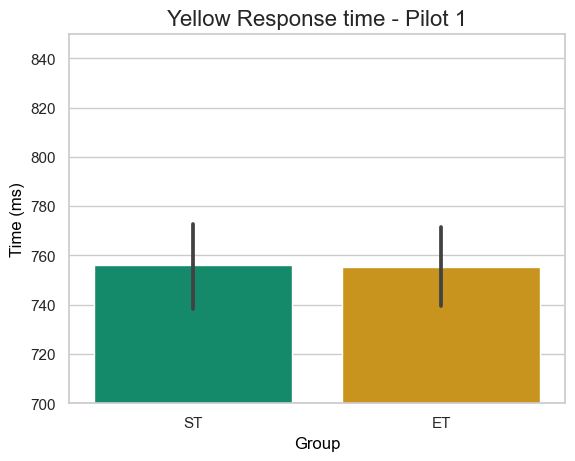

<Figure size 640x480 with 0 Axes>

In [163]:

# Define custom colors
custom_palette = {"ET": "#E69F00", "ST": "#009E73"}

# Create the bar plot with custom colors
ax = sns.barplot(data=df_RT_Yellow_cleaned, x="Group", y="Response time", palette=custom_palette)

# Set axis limits
plt.ylim(700, 850)

# Customize axis labels
ax.set_xlabel("Group", fontdict={'fontsize': 12, 'color': 'black'})
ax.set_ylabel("Time (ms)", fontdict={'fontsize': 12, 'color': 'black'})

plt.title('Yellow Response time - Pilot 1', fontsize=16)
# plt.xlabel('Group', fontsize=12)
# plt.ylabel('Correct Presses Percentage', fontsize=12)
# Save the figure
plt.savefig("response_time_buttons.png")

# Show the plot
plt.show()

plt.savefig("response_time_buttons.png")

### RT for dev

In [164]:
RTs_Dev = {}

for i in range(11, 15):
    RT = {'Blue': {}, 'Red': {}}
    dfs[i] = dfs[i][dfs[i].subId.isin(relevent_subIds[i])]
    # dfs[i] = dfs[i][~dfs[i]['subId'].isin(outliers_Dev['subId'])]
    for row in dfs[i][['correctFirstBluePressDevtest', 'blueChoiceDev']].dropna().iterrows():
        # print(row[1])
        # print()
        RT_blue_row = {}
        counter = 0
        for correctFirstBluePressDev in row[1].correctFirstBluePressDevtest:
            choices_before_press = [x for x in row[1].blueChoiceDev if x<correctFirstBluePressDev]
            # print(correctFirstRedPressButtons, choices_before_press)
            if len(choices_before_press)>0:
                RT_blue_row[counter] = correctFirstBluePressDev - choices_before_press[-1]
                counter += 1 
        # break         
        if len(RT_blue_row)>0:
            RT['Blue'][row[0]] = list(RT_blue_row.values())
    
    for row in dfs[i][['correctFirstRedPressDevtest', 'redChoiceDev']].dropna().iterrows():
        RT_red_row = {}
        counter = 0
        for correctFirstRedPressDev in row[1].correctFirstRedPressDevtest:
            choices_before_press = [x for x in row[1].redChoiceDev if x<correctFirstRedPressDev]
            if len(choices_before_press)>0:
                RT_red_row[counter] = correctFirstRedPressDev - choices_before_press[-1]
                counter += 1 
        if len(RT_red_row)>0:
            RT['Red'][row[0]] = list(RT_red_row.values())
    
    RTs_Dev[i] = pd.DataFrame(RT)


In [165]:
def to_list(a):
    if isinstance(a, float):
        return [a]
    return a

In [166]:
mean_RTs_Dev = {grp: pd.DataFrame({'Blue': RT.Blue.apply(lambda x: pd.Series({i: y for i,y in enumerate(to_list(x))})).T.mean(),
                  'Red': RT.Red.apply(lambda x: pd.Series({i: y for i,y in enumerate(to_list(x))})).T.mean()})
            for grp, RT in RTs_Dev.items()}

In [167]:
BandRST_Dev = pd.concat([mean_RTs_Dev[11]["Red"], mean_RTs_Dev[12]["Blue"]]).reset_index()
BandRST_Dev['Condition'] = 'Dev'
BandRST_Dev["Group"]="ST"
BandRST_NonDev = pd.concat([mean_RTs_Dev[11]["Blue"], mean_RTs_Dev[12]["Red"]]).reset_index()
BandRST_NonDev['Condition'] = 'nonDev'
BandRST_NonDev["Group"]="ST"
BandRET_Dev = pd.concat([mean_RTs_Dev[13]["Red"], mean_RTs_Dev[14]["Blue"]]).reset_index()
BandRET_Dev['Condition'] = 'Dev'
BandRET_Dev["Group"]="ET"
BandRET_NonDev = pd.concat([mean_RTs_Dev[13]["Blue"], mean_RTs_Dev[14]["Red"]]).reset_index()
BandRET_NonDev['Condition'] = 'nonDev'
BandRET_NonDev["Group"]="ET"
BandR_Dev = pd.concat([BandRST_Dev,BandRET_Dev])
BandR_Dev = BandR_Dev.drop(columns = "index").dropna()
BandR_Dev= BandR_Dev.rename(columns={0:"Response time"})
BandR_NonDev = pd.concat([BandRST_NonDev,BandRET_NonDev])
BandR_NonDev = BandR_NonDev.drop(columns = "index").dropna()
BandR_NonDev= BandR_NonDev.rename(columns={0:"Response time"})

In [168]:
BandRET_Dev = BandRET_Dev.set_index('index').rename(columns={0:'RT'})
BandRET_NonDev = BandRET_NonDev.set_index('index').rename(columns={0:'RT'})
BandRST_Dev = BandRST_Dev.set_index('index').rename(columns={0:'RT'}).dropna()
BandRST_NonDev = BandRST_NonDev.set_index('index').rename(columns={0:'RT'})


In [169]:
BandRST_Dev = BandRST_Dev.reset_index()
BandRST_NonDev = BandRST_NonDev.reset_index()
BandRST_Dev_indexNan = BandRST_Dev[BandRST_Dev['RT'].isna()]['index']

In [170]:
BandRST_NonDev = BandRST_NonDev[~BandRST_NonDev['index'].isin(BandRST_Dev_indexNan)]

#### Mixed ANOVA

In [171]:
devRT_ET = pd.concat([BandRET_Dev,BandRET_NonDev])
devRT_ST = pd.concat([BandRST_Dev,BandRST_NonDev])
BandR_ALL_Dev = pd.concat([devRT_ET,devRT_ST], axis = 0)
BandR_ALL_Dev = BandR_ALL_Dev.drop(columns=['index'])

In [172]:
# Test normality for each measure
print("Shapiro-Wilk test for 'ST':", shapiro(BandR_ALL_Dev[BandR_ALL_Dev['Group']=='ST']['RT'])) 
print("Shapiro-Wilk test for 'ET':", shapiro(BandR_ALL_Dev[BandR_ALL_Dev['Group']=='ET']['RT']))

Shapiro-Wilk test for 'ST': ShapiroResult(statistic=0.9137475490570068, pvalue=0.01412059273570776)
Shapiro-Wilk test for 'ET': ShapiroResult(statistic=nan, pvalue=1.0)


In [173]:
BandR_ALL_Dev['Pilot'] = 1

In [174]:
BandR_ALL_Dev.to_csv('BandR_ALL_Dev1.csv')

#### RT dev

In [176]:
BandR_Dev = BandR_Dev.reset_index()
BandR_Dev['index'] = BandR_Dev['index'] - 1

In [177]:
# Assuming your DataFrame is stored as 'df'
df = BandR_Dev

# Grouping by 'Group' and calculating Q1, Q3, and IQR
grouped = df.groupby('Group')['Response time'].describe()

# Calculating IQR and identifying outliers
def find_outliers(group):
    Q1 = group.quantile(0.25)
    Q3 = group.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = group[(group < lower_bound) | (group > upper_bound)]
    return outliers

# Apply the function to each group
outliers_RT_Dev = df.groupby('Group')['Response time'].apply(find_outliers)

# Print outliers
print(outliers_RT_Dev)

Group    
ET     12    325.0
ST     0     931.0
Name: Response time, dtype: float64


In [178]:
outliers_RT_Dev = pd.DataFrame(outliers_RT_Dev).reset_index()
outliers_RT_Dev_subIds = outliers_RT_Dev['level_1']


In [179]:
df_RT_Dev_cleaned = BandR_Dev[~BandR_Dev['index'].isin(outliers_RT_Dev_subIds)]

In [180]:

# Compare ET vs. ST 
data_st = df_RT_Dev_cleaned[df_RT_Dev_cleaned['Group']=='ST']['Response time']
data_et = df_RT_Dev_cleaned[df_RT_Dev_cleaned['Group']=='ET']['Response time']
n1_last, n2_last = len(data_et), len(data_st)

stat_last, p_last = mannwhitneyu(data_et, data_st)
r_last, z_last = compute_effect_size(stat_last, n1_last, n2_last)

# Print results
print(f"Mann-Whitney U test for 'last' between ET and ST: U = {stat_last}, p-value = {p_last}, Z = {z_last:.3f}, effect size r = {r_last:.3f}")



Mann-Whitney U test for 'last' between ET and ST: U = 33.0, p-value = 0.34774559891069756, Z = -0.980, effect size r = 0.225


In [181]:
df_RT_Dev_cleaned[df_RT_Dev_cleaned['Group']=='ST'].describe()

,index,Response time
count,10.00000,10.000000
mean,6.90000,702.004290
std,4.72464,60.558467
min,1.00000,604.779661
25%,3.25000,653.928154
50%,5.50000,710.285020
75%,10.75000,734.182500
max,14.00000,791.864865


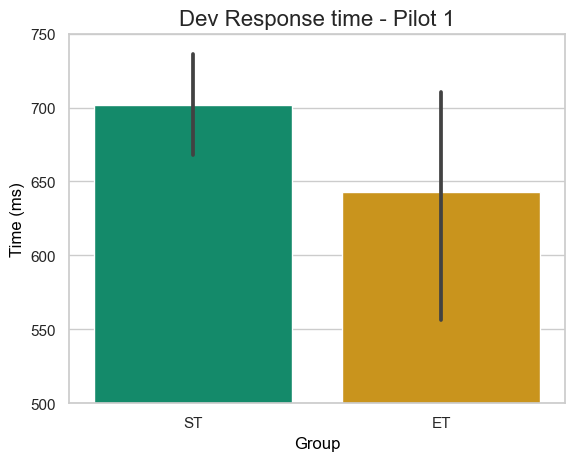

In [182]:
import plotly.express as px

# Define custom colors
custom_palette = {"ET": "#E69F00", "ST": "#009E73"}

# Create the bar plot with custom colors
ax = sns.barplot(data=df_RT_Dev_cleaned, x="Group", y="Response time", palette=custom_palette)

# Set axis limits
plt.ylim(500, 750)

# Customize axis labels
ax.set_xlabel("Group", fontdict={'fontsize': 12, 'color': 'black'})
ax.set_ylabel("Time (ms)", fontdict={'fontsize': 12, 'color': 'black'})

plt.title('Dev Response time - Pilot 1', fontsize=16)
# plt.xlabel('Group', fontsize=12)
# Save the figure
plt.savefig("response_time_dev.png")

# Show the plot
plt.show()

# plt.savefig("response_time_buttons.png")

In [ ]:
BandRST_Dev = pd.concat([mean_RTs_Dev[11]["Red"], mean_RTs_Dev[12]["Blue"]]).reset_index()
BandRST_NonDev = pd.concat([mean_RTs_Dev[11]["Blue"], mean_RTs_Dev[12]["Red"]]).reset_index()
BandRST_NonDev["Group"]="ST"
BandRST_Dev["Group"]="ST"
BandRET_Dev = pd.concat([mean_RTs_Dev[13]["Red"], mean_RTs_Dev[14]["Blue"]]).reset_index()
BandRET_NonDev = pd.concat([mean_RTs_Dev[13]["Blue"], mean_RTs_Dev[14]["Red"]]).reset_index()
BandRET_Dev["Group"]="ET"
BandRET_NonDev["Group"]="ET"
BandR_Dev = pd.concat([BandRST_Dev,BandRET_Dev])
BandR_Dev = BandR_Dev.drop(columns = "index").dropna()
BandR_Dev= BandR_Dev.rename(columns={0:"Response time"})
BandR_NonDev = pd.concat([BandRST_NonDev,BandRET_NonDev])
BandR_NonDev = BandR_NonDev.drop(columns = "index").dropna()
BandR_NonDev= BandR_NonDev.rename(columns={0:"Response time"})

In [ ]:
BandR_Dev = BandR_Dev.reset_index()
BandR_Dev['index'] = BandR_Dev['index'] - 1

In [ ]:
# Assuming your DataFrame is stored as 'df'
df = BandR_Dev

# Grouping by 'Group' and calculating Q1, Q3, and IQR
grouped = df.groupby('Group')['Response time'].describe()

# Calculating IQR and identifying outliers
def find_outliers(group):
    Q1 = group.quantile(0.25)
    Q3 = group.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = group[(group < lower_bound) | (group > upper_bound)]
    return outliers

# Apply the function to each group
outliers_RT_Dev = df.groupby('Group')['Response time'].apply(find_outliers)

# Print outliers
print(outliers_RT_Dev)

In [ ]:
outliers_RT_Dev = pd.DataFrame(outliers_RT_Dev).reset_index()
outliers_RT_Dev_subIds = outliers_RT_Dev['level_1']


In [ ]:
df_RT_Dev_cleaned = BandR_Dev[~BandR_Dev['index'].isin(outliers_RT_Dev_subIds)]

In [ ]:
# Test normality for each measure
print("Shapiro-Wilk test for 'ST':", shapiro(df_RT_Dev_cleaned[df_RT_Dev_cleaned['Group']=='ST']['Response time'])) 
print("Shapiro-Wilk test for 'ET':", shapiro(df_RT_Dev_cleaned[df_RT_Dev_cleaned['Group']=='ET']['Response time']))

In [ ]:

# Compare ET vs. ST 
data_st = df_RT_Dev_cleaned[df_RT_Dev_cleaned['Group']=='ST']['Response time']
data_et = df_RT_Dev_cleaned[df_RT_Dev_cleaned['Group']=='ET']['Response time']
n1_last, n2_last = len(data_et), len(data_st)

stat_last, p_last = mannwhitneyu(data_et, data_st)
r_last, z_last = compute_effect_size(stat_last, n1_last, n2_last)

# Print results
print(f"Mann-Whitney U test for 'last' between ET and ST: U = {stat_last}, p-value = {p_last}, Z = {z_last:.3f}, effect size r = {r_last:.3f}")



In [ ]:
df_RT_Dev_cleaned[df_RT_Dev_cleaned['Group']=='ET'].describe()

In [ ]:
import plotly.express as px

# Define custom colors
custom_palette = {"ET": "#E69F00", "ST": "#009E73"}

# Create the bar plot with custom colors
ax = sns.barplot(data=df_RT_Dev_cleaned, x="Group", y="Response time", palette=custom_palette)

# Set axis limits
plt.ylim(500, 750)

# Customize axis labels
ax.set_xlabel("Group", fontdict={'fontsize': 12, 'color': 'black'})
ax.set_ylabel("Time (ms)", fontdict={'fontsize': 12, 'color': 'black'})

plt.title('Dev Response time - Pilot 1', fontsize=16)
# plt.xlabel('Group', fontsize=12)
# Save the figure
plt.savefig("response_time_dev.png")

# Show the plot
plt.show()

# plt.savefig("response_time_buttons.png")

#### RT NonDev

In [ ]:
BandR_NonDev = BandR_NonDev.reset_index()
# BandR_NonDev['index'] = BandR_NonDev['index'] - 1

In [ ]:
# Assuming your DataFrame is stored as 'df'
df = BandR_NonDev

# Grouping by 'Group' and calculating Q1, Q3, and IQR
grouped = df.groupby('Group')['Response time'].describe()

# Calculating IQR and identifying outliers
def find_outliers(group):
    Q1 = group.quantile(0.25)
    Q3 = group.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = group[(group < lower_bound) | (group > upper_bound)]
    return outliers

# Apply the function to each group
outliers_RT_NonDev = df.groupby('Group')['Response time'].apply(find_outliers)

# Print outliers
print(outliers_RT_NonDev)

In [ ]:
outliers_RT_NonDev = pd.DataFrame(outliers_RT_NonDev).reset_index()
outliers_RT_NonDev_subIds = outliers_RT_NonDev['level_1']


In [ ]:
df_RT_NonDev_cleaned = BandR_NonDev[~BandR_NonDev['index'].isin(outliers_RT_NonDev_subIds)]

In [ ]:
# Test normality for each measure
print("Shapiro-Wilk test for 'ST':", shapiro(df_RT_NonDev_cleaned[df_RT_NonDev_cleaned['Group']=='ST']['Response time'])) 
print("Shapiro-Wilk test for 'ET':", shapiro(df_RT_NonDev_cleaned[df_RT_NonDev_cleaned['Group']=='ET']['Response time']))

In [ ]:

# Compare ET vs. ST 
data_st = df_RT_NonDev_cleaned[df_RT_NonDev_cleaned['Group']=='ST']['Response time']
data_et = df_RT_NonDev_cleaned[df_RT_NonDev_cleaned['Group']=='ET']['Response time']

n1_last, n2_last = len(data_et), len(data_st)

stat_last, p_last = mannwhitneyu(data_et, data_st)
r_last, z_last = compute_effect_size(stat_last, n1_last, n2_last)

# Print results
print(f"Mann-Whitney U test for 'last' between ET and ST: U = {stat_last}, p-value = {p_last}, Z = {z_last:.3f}, effect size r = {r_last:.3f}")



In [ ]:
df_RT_NonDev_cleaned[df_RT_NonDev_cleaned['Group']=='ET'].describe()

In [ ]:
import plotly.express as px

# Define custom colors
custom_palette = {"ET": "#E69F00", "ST": "#009E73"}

# Create the bar plot with custom colors
ax = sns.barplot(data=df_RT_NonDev_cleaned, x="Group", y="Response time", palette=custom_palette)

# Set axis limits
plt.ylim(500, 750)

# Customize axis labels
ax.set_xlabel("Group", fontdict={'fontsize': 12, 'color': 'black'})
ax.set_ylabel("Time (ms)", fontdict={'fontsize': 12, 'color': 'black'})

plt.title('NonDev Response time - Pilot 1', fontsize=16)
# plt.xlabel('Group', fontsize=12)
# plt.ylabel('Correct Presses Percentage', fontsize=12)
# Save the figure
plt.savefig("response_time_NonDev.png")

# Show the plot
plt.show()

# plt.savefig("response_time_buttons.png")

#### RT ET-Dev

In [ ]:
BandRET_Dev = BandRET_Dev.rename(columns={'RT':'Dev'}).drop(columns=['Group'])
BandRET_NonDev = BandRET_NonDev.rename(columns={'RT':'nonDev'})
ET_Dev = pd.concat([BandRET_NonDev, BandRET_Dev], axis=1)
# ET_Dev = ET_Dev.drop(columns=['Group','SubGroup'])

In [ ]:
ET_Dev = ET_Dev.reset_index()

In [ ]:
ET_Dev = ET_Dev.drop(columns=['index']).dropna()

In [ ]:
# Assuming your DataFrame is stored as 'df'
df = ET_Dev

# Grouping by 'Group' and calculating Q1, Q3, and IQR
grouped = df.groupby('index')['nonDev'].describe()

# Calculating IQR and identifying outliers
def find_outliers(group):
    Q1 = group.quantile(0.25)
    Q3 = group.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = group[(group < lower_bound) | (group > upper_bound)]
    return outliers

# Apply the function to each group
outliers_RT_ETDev = df.groupby('index')['nonDev'].apply(find_outliers)

# Print outliers
print(outliers_RT_ETDev)

In [ ]:
outliers_RT_ETDev = pd.DataFrame(outliers_RT_ETDev).reset_index()
outliers_RT_ETDev_subIds = outliers_RT_ETDev['level_1']


In [ ]:
df_RT_ETDev_cleaned = ET_Dev[~ET_Dev['index'].isin(outliers_RT_ETDev_subIds)]

In [ ]:
df_RT_ETDev_cleaned.dropna()

In [ ]:
# Test normality for each measure
print("Shapiro-Wilk test for 'ST':", shapiro(df_RT_ETDev_cleaned['Dev'])) 
print("Shapiro-Wilk test for 'ET':", shapiro(df_RT_ETDev_cleaned['nonDev']))

In [ ]:

# Wilcoxon test for ET group
stat_ET, p_ET = wilcoxon(df_RT_ETDev_cleaned['Dev'], df_RT_ETDev_cleaned['nonDev'])

# Compute the z-score manually
N1 = len(df_RT_ETDev_cleaned['Dev'])  # Number of paired observations
z1 = (p_ET - (N1 * (N1 + 1) / 4)) / np.sqrt(N1 * (N1 + 1) * (2 * N1 + 1) / 24)

# Compute effect size (r)
r1 = z1 / np.sqrt(N1)

print(f"Wilcoxon test for ET: Statistic = {stat_ET}, p-value = {p_ET}, Z score = {z1:.3f}, Effect Size (r) = {r1:.3f}")


In [ ]:
df_RT_ETDev_cleaned.describe()

In [ ]:
df_RT_ETDev_cleaned = df_RT_ETDev_cleaned.set_index('index')
df_RT_ETDev_cleaned = df_RT_ETDev_cleaned.melt()
df_RT_STDev_cleaned

In [ ]:
import plotly.express as px

# Define custom colors
custom_palette = {"Dev": "#E69F00", "nonDev": "#009E73"}

# Create the bar plot with custom colors
ax = sns.barplot(data=df_RT_ETDev_cleaned, x=df_RT_ETDev_cleaned["variable"], y=df_RT_ETDev_cleaned["value"], palette=custom_palette)

# Set axis limits
plt.ylim(500, 750)

# Customize axis labels
ax.set_xlabel("SubGroup", fontdict={'fontsize': 12, 'color': 'black'})
ax.set_ylabel("Time (ms)", fontdict={'fontsize': 12, 'color': 'black'})

plt.title('Dev Response time - ET group, Pilot 1', fontsize=16)
# plt.xlabel('Group', fontsize=12)
# plt.ylabel('Correct Presses Percentage', fontsize=12)
# Save the figure
plt.savefig("response_time_dev_ET.png")

# Show the plot
plt.show()

# plt.savefig("response_time_buttons.png")

#### RT ST-Dev

In [ ]:
BandRST_Dev = BandRST_Dev.rename(columns={0:'Dev'})#.drop(columns=['Group'])
BandRST_NonDev = BandRST_NonDev.rename(columns={0:'nonDev'})
ST_Dev = pd.concat([BandRST_NonDev, BandRST_Dev], axis=1)
# ST_Dev = ST_Dev.drop(columns=['Group','SubGroup'])

In [ ]:
ST_Dev = ST_Dev.reset_index()

In [ ]:
ST_Dev = ST_Dev.drop(columns=['index']).dropna()

In [ ]:
ST_Dev

In [ ]:
# ST_Dev = ST_Dev.drop(columns=['level_0','index'])
Dev_all_RT1 = pd.concat([ST_Dev,ET_Dev])
Dev_all_RT1["Pilot"] = 1

In [ ]:
Dev_all_RT1.to_csv('Dev_all_RT1.csv')

In [ ]:
Dev_all_RT1

In [ ]:
# Assuming your DataFrame is stored as 'df'
df = ST_Dev

# Grouping by 'Group' and calculating Q1, Q3, and IQR
grouped = df.groupby('index')['Dev'].describe()

# Calculating IQR and identifying outliers
def find_outliers(group):
    Q1 = group.quantile(0.25)
    Q3 = group.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = group[(group < lower_bound) | (group > upper_bound)]
    return outliers

# Apply the function to each group
outliers_RT_STDev = df.groupby('index')['nonDev'].apply(find_outliers)

# Print outliers
print(outliers_RT_STDev)

In [ ]:
outliers_RT_STDev = pd.DataFrame(outliers_RT_STDev).reset_index()
outliers_RT_STDev_subIds = outliers_RT_STDev['level_1']


In [ ]:
df_RT_STDev_cleaned = ST_Dev[~ST_Dev['index'].isin(outliers_RT_STDev_subIds)]

In [ ]:
df_RT_STDev_cleaned.dropna()

In [ ]:
# Test normality for each measure
print("Shapiro-Wilk test for 'ST':", shapiro(df_RT_STDev_cleaned['Dev'])) 
print("Shapiro-Wilk test for 'ET':", shapiro(df_RT_STDev_cleaned['nonDev']))

In [ ]:

# Wilcoxon test for ET group
stat_ST, p_ST = wilcoxon(df_RT_STDev_cleaned['Dev'], df_RT_STDev_cleaned['nonDev'])

# Compute the z-score manually
N1 = len(df_RT_STDev_cleaned['Dev'])  # Number of paired observations
z1 = (p_ET - (N1 * (N1 + 1) / 4)) / np.sqrt(N1 * (N1 + 1) * (2 * N1 + 1) / 24)

# Compute effect size (r)
r1 = z1 / np.sqrt(N1)

print(f"Wilcoxon test for ET: Statistic = {stat_ST}, p-value = {p_ST}, Z score = {z1:.3f}, Effect Size (r) = {r1:.3f}")


In [ ]:
df_RT_STDev_cleaned.describe()

In [ ]:
df_RT_STDev_cleaned = df_RT_STDev_cleaned.set_index('index')
df_RT_STDev_cleaned = df_RT_STDev_cleaned.melt()
# df_RT_STDev_cleaned

In [ ]:
import plotly.express as px

# Define custom colors
custom_palette = {"Dev": "#E69F00", "nonDev": "#009E73"}

# Create the bar plot with custom colors
ax = sns.barplot(data=df_RT_STDev_cleaned, x=df_RT_STDev_cleaned['variable'], y=df_RT_STDev_cleaned['value'], palette=custom_palette)

# Set axis limits
plt.ylim(500, 800)

# Customize axis labels
ax.set_xlabel("SubGroup", fontdict={'fontsize': 12, 'color': 'black'})
ax.set_ylabel("Time (ms)", fontdict={'fontsize': 12, 'color': 'black'})

plt.title('Dev Response time - ST group, Pilot 1', fontsize=16)
# plt.xlabel('Group', fontsize=12)
# plt.ylabel('Correct Presses Percentage', fontsize=12)
# Save the figure
plt.savefig("response_time_dev_ST.png")

# Show the plot
plt.show()

# plt.savefig("response_time_buttons.png")